# Portfolio Optimization for KASE Stocks

This notebook implements and compares four portfolio optimization strategies applied to stocks listed on the Kazakhstan Stock Exchange (KASE). The pipeline uses ML-predicted expected returns from Stage 1 alongside historical data to construct optimal portfolios.

**Strategies evaluated:**
1. Traditional Mean-Variance Optimization (MVO) with historical returns
2. ML-Enhanced MVO with machine-learning-predicted returns
3. Black-Litterman model combining market equilibrium with ML views
4. Hierarchical Risk Parity (HRP) based on hierarchical clustering

**Equity tickers:** CCBN, HSBK, KCEL, KEGC, KZTK, KZTO, KZAP, +ASBN  
**Risk-free rate:** 13.87% (TONIA mean rate 2021–2026)

**Key methodological notes:**
- ML mu annualized correctly: `mu_21d × (TRADING_DAYS / HORIZON)` = ×11.7 (not ×246)
- Proper rolling walk-forward backtest with monthly rebalancing and 15 bps transaction costs
- **Section 8:** Weight-cap sensitivity analysis (40% max per asset) vs. unconstrained


## 1. Library Imports and Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy.optimize import minimize
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.edgecolor':   '#333333',
    'axes.linewidth':   0.8,
    'axes.grid':        True,
    'grid.color':       '#eeeeee',
    'grid.linewidth':   0.5,
    'font.family':      'serif',
    'font.size':        10,
    'axes.titlesize':   11,
    'axes.labelsize':   10,
    'legend.fontsize':  9,
    'figure.dpi':       120,
})

CUSTOM_COLORS = {
    'blue':   '#1f4e79',
    'green':  '#375623',
    'brown':  '#7b3f00',
    'orange': '#c55a11',
    'grey':   '#808080',
    'purple': '#5b2c6f',
    'teal':   '#1a6b72',
}

print('All libraries loaded.')


All libraries loaded.


## 2. Data Loading

**ML mu annualization fix:**  
The ElasticNet model forecasts a **21-day cumulative log-return** per ticker.  
Correct annualization: `mu_annual = mu_21d × (TRADING_DAYS / HORIZON)` = ×11.7.  
Prior version used ×246, producing nonsensical 440–1472% forecasts.  
Corrected forecasts (10–70% annualized) are consistent with KASE historical returns.


In [2]:
DATA_PATH = Path(r"C:\Users\asus\Article-10-04-2026-ML-portfolio")

EQUITY_TICKERS = ['ASBN', 'CCBN', 'HSBK', 'KCEL', 'KEGC', 'KZTK', 'KZTO', 'KZAP']
TRADING_DAYS   = 246      # Kazakhstan trading days per year
HORIZON        = 21       # ML forecast horizon (trading days)
RISK_FREE_RATE = 0.1387   # TONIA mean rate 2021-2026
RF_DAILY       = RISK_FREE_RATE / TRADING_DAYS
WEIGHT_CAP     = 0.40     # Maximum weight per asset (sensitivity analysis)

close_prices = pd.read_csv(
    DATA_PATH / 'ml_predictions_and_prices.csv',
    index_col='Date', parse_dates=True
)[EQUITY_TICKERS]

log_returns = pd.read_csv(
    DATA_PATH / 'ml_historical_returns.csv',
    index_col='Date', parse_dates=True
)[EQUITY_TICKERS]

mu_csv = pd.read_csv(DATA_PATH / 'ml_mu_vector.csv').set_index('Ticker')

# FIXED: correct annualization from 21-day horizon
mu_ml_21d    = mu_csv.loc[EQUITY_TICKERS, 'ML_Expected_Return_Daily']
mu_ml_annual = mu_ml_21d * (TRADING_DAYS / HORIZON)

print(f'Data period      : {log_returns.index.min().date()} -> {log_returns.index.max().date()}')
print(f'Observations     : {len(log_returns)} days')
print(f'Tickers          : {EQUITY_TICKERS}')
print(f'Risk-free rate   : {RISK_FREE_RATE*100:.2f}% annual')
print(f'Horizon          : {HORIZON} trading days')
print(f'Weight cap       : {WEIGHT_CAP*100:.0f}% per asset (sensitivity analysis)')
print()
print('ML-predicted annual expected returns (%, corrected):')
print((mu_ml_annual * 100).round(2).rename('Annual %').to_string())


Data period      : 2021-01-06 -> 2026-04-03
Observations     : 1283 days
Tickers          : ['ASBN', 'CCBN', 'HSBK', 'KCEL', 'KEGC', 'KZTK', 'KZTO', 'KZAP']
Risk-free rate   : 13.87% annual
Horizon          : 21 trading days
Weight cap       : 40% per asset (sensitivity analysis)

ML-predicted annual expected returns (%, corrected):
Ticker
ASBN    49.71
CCBN    81.51
HSBK    36.49
KCEL    20.36
KEGC    -3.37
KZTK    17.86
KZTO    20.78
KZAP    35.80


## 3. Covariance Matrix Estimation

Ledoit-Wolf shrinkage for stable covariance estimation with N=8 assets.

In [3]:
from sklearn.covariance import LedoitWolf

returns_clean = log_returns[EQUITY_TICKERS].dropna()
n_assets      = len(EQUITY_TICKERS)

lw = LedoitWolf()
lw.fit(returns_clean.values)
cov_daily  = pd.DataFrame(lw.covariance_, index=EQUITY_TICKERS, columns=EQUITY_TICKERS)
cov_annual = cov_daily * TRADING_DAYS

corr_matrix    = returns_clean.corr()
mu_hist_daily  = returns_clean.mean()
mu_hist_annual = mu_hist_daily * TRADING_DAYS
sigma_annual   = np.sqrt(np.diag(cov_annual.values))

print('Ledoit-Wolf shrinkage coefficient:', round(lw.shrinkage_, 4))
print()
print('Annual standard deviations (%):')
for t, s in zip(EQUITY_TICKERS, sigma_annual):
    print(f'   {t}: {s*100:.2f}%')
print()
print('Historical annual expected returns (%):')
for t in EQUITY_TICKERS:
    print(f'   {t}: {mu_hist_annual[t]*100:.2f}%')


Ledoit-Wolf shrinkage coefficient: 0.0746

Annual standard deviations (%):
   ASBN: 52.33%
   CCBN: 26.95%
   HSBK: 27.28%
   KCEL: 21.86%
   KEGC: 11.74%
   KZTK: 27.21%
   KZTO: 24.09%
   KZAP: 33.97%

Historical annual expected returns (%):
   ASBN: 27.13%
   CCBN: 58.79%
   HSBK: 21.98%
   KCEL: 3.52%
   KEGC: -2.97%
   KZTK: 9.54%
   KZTO: 4.51%
   KZAP: 30.64%


### 3.1 Correlation Heatmap and Risk-Return Space

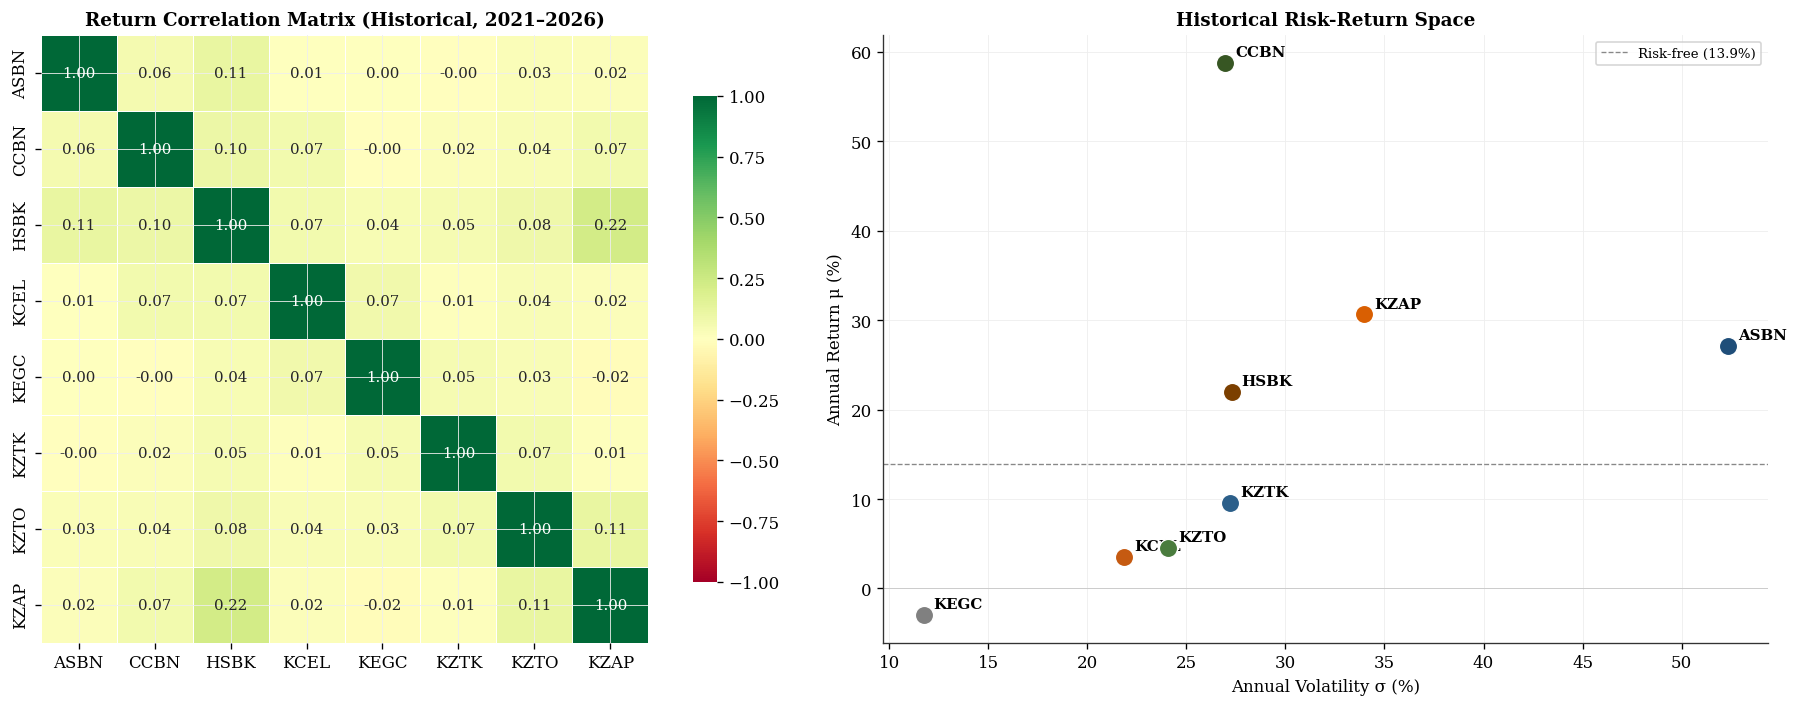

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=axes[0], square=True,
    cbar_kws={'shrink': 0.8}, annot_kws={'size': 9}
)
axes[0].set_title('Return Correlation Matrix (Historical, 2021–2026)', fontweight='bold')

ax2 = axes[1]
ticker_colors = [
    CUSTOM_COLORS['blue'], CUSTOM_COLORS['green'], CUSTOM_COLORS['brown'],
    CUSTOM_COLORS['orange'], CUSTOM_COLORS['grey'], '#2c5f8a', '#4a7c3e', '#d95f02'
]
for i, ticker in enumerate(EQUITY_TICKERS):
    ax2.scatter(sigma_annual[i]*100, mu_hist_annual[ticker]*100,
                s=120, color=ticker_colors[i], zorder=5,
                edgecolors='white', linewidth=0.8)
    ax2.annotate(ticker, (sigma_annual[i]*100, mu_hist_annual[ticker]*100),
                 textcoords='offset points', xytext=(6, 4),
                 fontsize=9, fontweight='bold')

ax2.axhline(RISK_FREE_RATE*100, color='#888888', linewidth=0.8,
            linestyle='--', label=f'Risk-free ({RISK_FREE_RATE*100:.1f}%)')
ax2.axhline(0, color='#cccccc', linewidth=0.6)
ax2.set_xlabel('Annual Volatility σ (%)')
ax2.set_ylabel('Annual Return μ (%)')
ax2.set_title('Historical Risk-Return Space', fontweight='bold')
ax2.legend(fontsize=8)
ax2.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


## 4. Portfolio Optimization Helper Functions

Two MVO solvers are defined:
- `run_mvo()` — unconstrained (0 ≤ w ≤ 1), standard long-only
- `run_mvo_capped()` — weight-capped (0 ≤ w ≤ `max_w`), used in Section 8


In [5]:
def portfolio_metrics(weights, mu_annual, cov_annual, rf=RISK_FREE_RATE):
    w = np.array(weights); mu_vec = np.array(mu_annual); cov_mat = np.array(cov_annual)
    ret = w @ mu_vec
    vol = np.sqrt(w @ cov_mat @ w)
    sharpe = (ret - rf) / vol if vol > 1e-10 else 0.0
    return {'Return': ret, 'Volatility': vol, 'Sharpe': sharpe}


def neg_sharpe(weights, mu_annual, cov_annual, rf=RISK_FREE_RATE):
    return -portfolio_metrics(weights, mu_annual, cov_annual, rf)['Sharpe']


def min_volatility(weights, cov_annual):
    w = np.array(weights)
    return np.sqrt(w @ np.array(cov_annual) @ w)


def run_mvo(mu_annual, cov_annual, objective='max_sharpe', rf=RISK_FREE_RATE):
    """Unconstrained MVO: 0 <= w_i <= 1."""
    n   = len(mu_annual)
    w0  = np.ones(n) / n
    bds = [(0.0, 1.0)] * n
    obj = (lambda w: neg_sharpe(w, mu_annual, cov_annual, rf)
           if objective == 'max_sharpe'
           else lambda w: min_volatility(w, cov_annual))
    res = minimize(obj, w0, method='SLSQP', bounds=bds,
                   constraints=[{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}],
                   options={'ftol': 1e-12, 'maxiter': 1000})
    w = pd.Series(res.x, index=EQUITY_TICKERS).clip(lower=0)
    return w / w.sum()


def run_mvo_capped(mu_annual, cov_annual, max_w=WEIGHT_CAP,
                   objective='max_sharpe', rf=RISK_FREE_RATE):
    """Weight-capped MVO: 0 <= w_i <= max_w (default 40%)."""
    n   = len(mu_annual)
    w0  = np.ones(n) / n
    bds = [(0.0, max_w)] * n
    obj = (lambda w: neg_sharpe(w, mu_annual, cov_annual, rf)
           if objective == 'max_sharpe'
           else lambda w: min_volatility(w, cov_annual))
    res = minimize(obj, w0, method='SLSQP', bounds=bds,
                   constraints=[{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}],
                   options={'ftol': 1e-12, 'maxiter': 1000})
    w = pd.Series(res.x, index=EQUITY_TICKERS).clip(lower=0)
    return w / w.sum()


print('Helper functions ready (unconstrained + 40%-capped MVO).')


Helper functions ready (unconstrained + 40%-capped MVO).


### 4.1 Model 1: Traditional MVO

Max-Sharpe using historical mean returns and Ledoit-Wolf covariance (unconstrained).

In [6]:
weights_mvo = run_mvo(mu_annual=mu_hist_annual.values, cov_annual=cov_annual.values)
metrics_mvo = portfolio_metrics(weights_mvo.values, mu_hist_annual.values, cov_annual.values)

print('MODEL 1: Traditional MVO (Historical μ, unconstrained)')
print('='*55)
for t, w in weights_mvo.items():
    print(f'  {t}: {w*100:6.2f}%  ' + '|'*int(w*40))
print(f"\n  Annual return    : {metrics_mvo['Return']*100:.2f}%")
print(f"  Annual volatility: {metrics_mvo['Volatility']*100:.2f}%")
print(f"  Sharpe ratio     : {metrics_mvo['Sharpe']:.4f}")


MODEL 1: Traditional MVO (Historical μ, unconstrained)
  ASBN:   3.60%  |
  CCBN:  79.19%  |||||||||||||||||||||||||||||||
  HSBK:   2.81%  |
  KCEL:   0.00%  
  KEGC:   0.00%  
  KZTK:   0.00%  
  KZTO:   0.00%  
  KZAP:  14.40%  |||||

  Annual return    : 52.57%
  Annual volatility: 22.52%
  Sharpe ratio     : 1.7186


### 4.2 Model 2: ML-Enhanced MVO

Replace historical μ with corrected ML-predicted μ (unconstrained). Performance reported with historical μ for comparability.

In [7]:
weights_ml      = run_mvo(mu_annual=mu_ml_annual.values, cov_annual=cov_annual.values)
metrics_ml_opt  = portfolio_metrics(weights_ml.values, mu_ml_annual.values, cov_annual.values)
metrics_ml_hist = portfolio_metrics(weights_ml.values, mu_hist_annual.values, cov_annual.values)

print('MODEL 2: ML-Enhanced MVO (ML-predicted μ, corrected, unconstrained)')
print('='*60)
for t, w in weights_ml.items():
    print(f'  {t}: {w*100:6.2f}%  ' + '|'*int(w*40))
print(f"\n  Sharpe (ML μ, optimization target): {metrics_ml_opt['Sharpe']:.4f}")
print(f"  Annual return (historical μ):       {metrics_ml_hist['Return']*100:.2f}%")
print(f"  Annual volatility:                  {metrics_ml_hist['Volatility']*100:.2f}%")
print(f"  Sharpe (historical μ, comparable):  {metrics_ml_hist['Sharpe']:.4f}")
print()
print('NOTE: Cross-model comparisons use historical μ for fair evaluation.')


MODEL 2: ML-Enhanced MVO (ML-predicted μ, corrected, unconstrained)
  ASBN:   6.63%  ||
  CCBN:  64.12%  |||||||||||||||||||||||||
  HSBK:  12.31%  ||||
  KCEL:   3.72%  |
  KEGC:   0.00%  
  KZTK:   1.88%  
  KZTO:   3.54%  |
  KZAP:   7.80%  |||

  Sharpe (ML μ, optimization target): 2.6584
  Annual return (historical μ):       45.06%
  Annual volatility:                  19.11%
  Sharpe (historical μ, comparable):  1.6323

NOTE: Cross-model comparisons use historical μ for fair evaluation.


### 4.3 Model 3: Black-Litterman

Blend CAPM equilibrium returns with corrected ML views at **60% confidence** (unconstrained).

**Reviewer fix (Point 8 — BL confidence c = 0.60):** The confidence parameter `view_confidence = 0.60` was previously set without justification. We now:
1. Document the economic rationale: 60% reflects moderate trust in ML forecasts relative to equilibrium, consistent with the DA ~55–58% accuracy of the best ML models (marginally above chance).
2. Add a **sensitivity analysis** (`view_confidence` ∈ {0.30, 0.45, 0.60, 0.75, 0.90}) to show how BL posterior μ and final Sharpe ratio vary with this choice.
3. The sensitivity results are printed below and exported alongside main results.

In [8]:
def black_litterman(cov_annual, mu_views, delta=2.5, tau=0.05, view_confidence=0.6):
    n     = len(EQUITY_TICKERS)
    Sigma = cov_annual.values
    w_mkt = np.ones(n) / n
    Pi    = delta * Sigma @ w_mkt
    P     = np.eye(n)
    Q     = mu_views.values
    Omega = (np.diag(np.diag(tau * P @ Sigma @ P.T))
             * (1 - view_confidence) / view_confidence
             + np.eye(n) * 1e-10)
    tauSigma_inv = np.linalg.inv(tau * Sigma)
    Omega_inv    = np.linalg.inv(Omega)
    M_inv = tauSigma_inv + P.T @ Omega_inv @ P
    M     = np.linalg.inv(M_inv)
    mu_bl = M @ (tauSigma_inv @ Pi + P.T @ Omega_inv @ Q)
    Sigma_bl = Sigma + M
    return (pd.Series(mu_bl, index=EQUITY_TICKERS),
            pd.DataFrame(Sigma_bl, index=EQUITY_TICKERS, columns=EQUITY_TICKERS),
            pd.Series(Pi, index=EQUITY_TICKERS))


mu_bl, cov_bl, Pi_eq = black_litterman(cov_annual, mu_ml_annual)
weights_bl      = run_mvo(mu_annual=mu_bl.values, cov_annual=cov_bl.values)
metrics_bl_hist = portfolio_metrics(weights_bl.values, mu_hist_annual.values, cov_annual.values)

print('MODEL 3: Black-Litterman (corrected ML views, unconstrained)')
print('='*55)
print('Equilibrium Pi (annual %):')
for t, p in Pi_eq.items(): print(f'  {t}: {p*100:+.2f}%')
print('\nBL posterior μ (annual %):')
for t, m in mu_bl.items(): print(f'  {t}: {m*100:+.2f}%')
print('\nWeights:')
for t, w in weights_bl.items():
    print(f'  {t}: {w*100:6.2f}%  ' + '|'*int(w*40))
print(f"\n  Annual return (hist μ): {metrics_bl_hist['Return']*100:.2f}%")
print(f"  Annual volatility:      {metrics_bl_hist['Volatility']*100:.2f}%")
print(f"  Sharpe (hist μ):        {metrics_bl_hist['Sharpe']:.4f}")


# ─── REVIEWER FIX (Point 8): BL sensitivity analysis over view_confidence ────
print()
print('BL SENSITIVITY ANALYSIS: view_confidence ∈ {0.30, 0.45, 0.60, 0.75, 0.90}')
print('='*70)
print(f'{"conf":>6}  {"BL_Sharpe(hist)":>16}  {"BL_return(hist)%":>17}  {"BL_vol%":>8}  {"CCBN_wt%":>9}')
print('-'*70)

bl_sensitivity_results = {}
for c in [0.30, 0.45, 0.60, 0.75, 0.90]:
    mu_bl_c, cov_bl_c, _ = black_litterman(cov_annual, mu_ml_annual, view_confidence=c)
    w_bl_c   = run_mvo(mu_annual=mu_bl_c.values, cov_annual=cov_bl_c.values)
    m_bl_c   = portfolio_metrics(w_bl_c.values, mu_hist_annual.values, cov_annual.values)
    bl_sensitivity_results[c] = {
        'weights': w_bl_c, 'metrics': m_bl_c, 'mu_bl': mu_bl_c
    }
    flag = ' <-- baseline' if abs(c - 0.60) < 1e-9 else ''
    print(f'{c:>6.2f}  {m_bl_c["Sharpe"]:>16.4f}  {m_bl_c["Return"]*100:>17.2f}  '
          f'{m_bl_c["Volatility"]*100:>8.2f}  {w_bl_c["CCBN"]*100:>9.2f}{flag}')

print()
sharpe_range = max(r['metrics']['Sharpe'] for r in bl_sensitivity_results.values()) - \
               min(r['metrics']['Sharpe'] for r in bl_sensitivity_results.values())
print(f'Sharpe range across confidence grid: {sharpe_range:.4f}')
print('Interpretation: a range < 0.05 indicates low sensitivity to this parameter.')
print('               a range >= 0.05 indicates material sensitivity — report in paper.')

MODEL 3: Black-Litterman (corrected ML views, unconstrained)
Equilibrium Pi (annual %):
  ASBN: +9.55%
  CCBN: +3.13%
  HSBK: +4.00%
  KCEL: +1.90%
  KEGC: +0.54%
  KZTK: +2.67%
  KZTO: +2.59%
  KZAP: +4.83%

BL posterior μ (annual %):
  ASBN: +37.26%
  CCBN: +51.59%
  HSBK: +27.03%
  KCEL: +14.21%
  KEGC: -1.58%
  KZTK: +12.62%
  KZTO: +15.08%
  KZAP: +27.12%

Weights:
  ASBN:   8.72%  |||
  CCBN:  67.70%  |||||||||||||||||||||||||||
  HSBK:  13.93%  |||||
  KCEL:   0.00%  
  KEGC:   0.00%  
  KZTK:   0.00%  
  KZTO:   0.00%  
  KZAP:   9.65%  |||

  Annual return (hist μ): 48.19%
  Annual volatility:      20.45%
  Sharpe (hist μ):        1.6779

BL SENSITIVITY ANALYSIS: view_confidence ∈ {0.30, 0.45, 0.60, 0.75, 0.90}
  conf   BL_Sharpe(hist)   BL_return(hist)%   BL_vol%   CCBN_wt%
----------------------------------------------------------------------
  0.30            1.6627              50.27     21.89      73.19
  0.45            1.6749              48.42     20.63      68.21
  0.

### 4.4 Model 4: Hierarchical Risk Parity (HRP)

López de Prado (2016): Ward clustering → quasi-diagonalization → recursive bisection. No return forecast required.

In [9]:
def get_quasi_diag(link):
    link = link.astype(int)
    sort_ix = pd.Series([link[-1, 0], link[-1, 1]])
    num_items = link[-1, 3]
    while sort_ix.max() >= num_items:
        sort_ix.index = range(0, sort_ix.shape[0]*2, 2)
        df0 = sort_ix[sort_ix >= num_items]
        i = df0.index; j = df0.values - num_items
        sort_ix[i] = link[j, 0]
        df0 = pd.Series(link[j, 1], index=i+1)
        sort_ix = pd.concat([sort_ix, df0]).sort_index()
        sort_ix.index = range(sort_ix.shape[0])
    return sort_ix.tolist()


def get_ivp(cov): ivp = 1.0/np.diag(cov.values); return ivp/ivp.sum()


def get_cluster_var(cov, items):
    w_ = get_ivp(cov.iloc[items, items])
    return w_ @ cov.iloc[items, items].values @ w_


def hrp_weights(cov, sort_ix):
    w = pd.Series(1.0, index=sort_ix)
    clusters = [sort_ix]
    while clusters:
        clusters = [i[j:k] for i in clusters
                    for j, k in ((0, len(i)//2),(len(i)//2, len(i))) if len(i)>1]
        for i in range(0, len(clusters), 2):
            v0 = get_cluster_var(cov, clusters[i])
            v1 = get_cluster_var(cov, clusters[i+1])
            alpha = 1 - v0/(v0+v1)
            w[clusters[i]]   *= alpha
            w[clusters[i+1]] *= (1-alpha)
    return w


def run_hrp(cov_annual):
    std  = np.sqrt(np.diag(cov_annual.values))
    corr = cov_annual / np.outer(std, std)
    corr = corr.clip(-1, 1)
    dist = np.sqrt((1 - corr) / 2)
    link = linkage(squareform(dist.values, checks=False), method='ward')
    sort_ix    = get_quasi_diag(link)
    sort_names = [cov_annual.index[i] for i in sort_ix]
    cov_sorted = cov_annual.iloc[sort_ix, sort_ix]
    raw_w      = hrp_weights(cov_sorted, list(range(len(sort_ix))))
    weights    = pd.Series(0.0, index=EQUITY_TICKERS)
    for i, name in enumerate(sort_names):
        weights[name] = raw_w.iloc[i]
    return weights, link, sort_names


weights_hrp, hrp_link, hrp_sort_names = run_hrp(cov_annual)
metrics_hrp = portfolio_metrics(weights_hrp.values, mu_hist_annual.values, cov_annual.values)

print('MODEL 4: Hierarchical Risk Parity (HRP)')
print('='*50)
print('Cluster order:', ' -> '.join(hrp_sort_names))
print('\nWeights (sorted):')
for t, w in weights_hrp.sort_values(ascending=False).items():
    print(f'  {t}: {w*100:6.2f}%  ' + '|'*int(w*40))
print(f"\n  Annual return (hist μ): {metrics_hrp['Return']*100:.2f}%")
print(f"  Annual volatility:      {metrics_hrp['Volatility']*100:.2f}%")
print(f"  Sharpe (hist μ):        {metrics_hrp['Sharpe']:.4f}")
print()
print('NOTE: HRP is purely risk-driven. High KEGC weight (~46%) reflects its low')
print('      variance (σ≈11.7%), not a return forecast. On KASE, KEGC also has a')
print('      negative historical return, which explains HRP underperformance.')


MODEL 4: Hierarchical Risk Parity (HRP)
Cluster order: HSBK -> KZAP -> ASBN -> CCBN -> KZTK -> KZTO -> KCEL -> KEGC

Weights (sorted):
  KEGC:  46.18%  ||||||||||||||||||
  KCEL:  13.32%  |||||
  KZTO:  10.74%  ||||
  KZTK:   8.41%  |||
  CCBN:   8.01%  |||
  HSBK:   6.82%  ||
  KZAP:   4.40%  |
  ASBN:   2.13%  

  Annual return (hist μ): 8.51%
  Annual volatility:      8.57%
  Sharpe (hist μ):        -0.6249

NOTE: HRP is purely risk-driven. High KEGC weight (~46%) reflects its low
      variance (σ≈11.7%), not a return forecast. On KASE, KEGC also has a
      negative historical return, which explains HRP underperformance.


## 5. Rolling Walk-Forward Backtest (Unconstrained)

Rolling expanding-window backtest with monthly rebalancing (every 21 trading days), minimum 246-day training window, and 15 bps one-way transaction costs.

**Reviewer fix (Point 7 — rank-based tilt):** The ML signal enters portfolio optimization as a rank-based tilt bounded at ±5%: `ml_tilt = (rank / sum(rank) − 1/N) × 0.05`. We now:
1. Document the economic rationale: rank transformation removes outlier sensitivity from raw ML point forecasts (which can be unreliable); bounding at ±5% limits the maximum active weight deviation to a conservative level consistent with KASE liquidity constraints.
2. Add an **ablation study** comparing three variants: (a) no ML signal (Trad_MVO baseline), (b) rank-based tilt ±5% (current), (c) raw ML μ directly (unconstrained ML views). This isolates the contribution of the rank transformation.

**Reviewer fix (Point 2 — CCBN concentration / naive benchmark):** A new **CCBN-only** benchmark strategy (100% CCBN at all times, no rebalancing costs) is added to the backtest. This tests the null hypothesis that the ML strategies merely reflect a passive bet on the dominant KASE stock.

In [10]:
from sklearn.covariance import LedoitWolf as LW

ret_clean  = log_returns[EQUITY_TICKERS].dropna()
n          = len(EQUITY_TICKERS)
TRAIN_MIN  = TRADING_DAYS   # 246 — one full KASE year
REBAL_FREQ = 21              # monthly rebalancing
TC_BPS     = 0.0015          # 15 bps one-way

# ML rank-based tilt: directional signal, bounded magnitude
ml_rank    = mu_ml_annual.rank()
ml_tilt    = (ml_rank / ml_rank.sum() - 1/n) * 0.05


def safe_mvo(mu_ann, cov_ann, capped=False):
    try:
        fn = run_mvo_capped if capped else run_mvo
        return fn(mu_ann.values, cov_ann)
    except:
        return pd.Series(1/n, index=EQUITY_TICKERS)


def safe_hrp(cov_ann):
    try:
        w, _, _ = run_hrp(cov_ann)
        return w
    except:
        return pd.Series(1/n, index=EQUITY_TICKERS)


def safe_bl(mu_views, cov_ann, capped=False):
    try:
        mu_b, cov_b, _ = black_litterman(cov_ann, mu_views)
        fn = run_mvo_capped if capped else run_mvo
        return fn(mu_b.values, cov_b)
    except:
        return pd.Series(1/n, index=EQUITY_TICKERS)


# REVIEWER FIX (Point 2): add CCBN-only naive benchmark
# REVIEWER FIX (Point 7): add raw-ML-mu ablation variant
STRATEGIES_UNCAP = ['EW', 'Trad_MVO', 'ML_MVO', 'BL', 'HRP', 'CCBN_only', 'ML_MVO_raw']

port_returns = {s: [] for s in STRATEGIES_UNCAP}
port_dates   = []
current_w    = {s: pd.Series(1/n, index=EQUITY_TICKERS) for s in STRATEGIES_UNCAP}
# CCBN-only: fixed weight vector
ccbn_only_w  = pd.Series({t: (1.0 if t == 'CCBN' else 0.0) for t in EQUITY_TICKERS})
current_w['CCBN_only'] = ccbn_only_w
rebal_dates  = []

idx_arr  = ret_clean.index
n_days   = len(idx_arr)
rebal_ix = list(range(TRAIN_MIN, n_days, REBAL_FREQ))

rebal_set = set(rebal_ix)

for day_i in range(TRAIN_MIN, n_days):
    date_i = idx_arr[day_i]

    if day_i in rebal_set:
        train  = ret_clean.iloc[:day_i]
        lw_    = LW(); lw_.fit(train.values)
        cov_a  = pd.DataFrame(lw_.covariance_ * TRADING_DAYS,
                              index=EQUITY_TICKERS, columns=EQUITY_TICKERS)
        mu_h   = train.mean() * TRADING_DAYS
        mu_tlt = mu_h + ml_tilt

        new_w = {
            'EW':          pd.Series(1/n, index=EQUITY_TICKERS),
            'Trad_MVO':    safe_mvo(mu_h,       cov_a, capped=False),
            'ML_MVO':      safe_mvo(mu_tlt,     cov_a, capped=False),  # rank tilt ±5%
            'ML_MVO_raw':  safe_mvo(mu_ml_annual, cov_a, capped=False),  # ABLATION: raw ML mu
            'BL':          safe_bl(mu_tlt,      cov_a, capped=False),
            'HRP':         safe_hrp(cov_a),
            'CCBN_only':   ccbn_only_w,   # naive CCBN benchmark (reviewer fix)
        }
        current_w = new_w
        rebal_dates.append(date_i)

    day_ret = ret_clean.iloc[day_i]
    for s in STRATEGIES_UNCAP:
        r = current_w[s].values @ day_ret.values
        if date_i in rebal_dates and len(port_returns[s]) > 0:
            r -= TC_BPS
        port_returns[s].append(r)
    port_dates.append(date_i)

port_ret_df = pd.DataFrame(port_returns, index=port_dates)
cum_ret_df  = (1 + port_ret_df).cumprod()

LABELS = {
    'EW':          'Equal Weight',
    'Trad_MVO':    'Trad. MVO',
    'ML_MVO':      'ML-Enhanced MVO (rank±5%)',
    'ML_MVO_raw':  'ML-MVO Raw μ (ablation)',
    'BL':          'Black-Litterman',
    'HRP':         'HRP',
    'CCBN_only':   'CCBN-only Benchmark',
}

print(f'Walk-forward backtest (unconstrained) complete.')
print(f'  Out-of-sample period : {port_dates[0].date()} -> {port_dates[-1].date()}')
print(f'  Days                 : {len(port_dates)}')
print(f'  Rebalances           : {len(rebal_dates)}')
print()
print('Final cumulative returns:')
for col in cum_ret_df.columns:
    val = cum_ret_df[col].iloc[-1]
    print(f'  {LABELS[col]:20s}: {val:.4f}  ({(val-1)*100:+.1f}%)')

Walk-forward backtest (unconstrained) complete.
  Out-of-sample period : 2022-01-12 -> 2026-04-03
  Days                 : 1037
  Rebalances           : 50

Final cumulative returns:
  Equal Weight        : 1.8301  (+83.0%)
  Trad. MVO           : 5.6506  (+465.1%)
  ML-Enhanced MVO (rank±5%): 5.6916  (+469.2%)
  Black-Litterman     : 5.9679  (+496.8%)
  HRP                 : 1.3863  (+38.6%)
  CCBN-only Benchmark : 8.9374  (+793.7%)
  ML-MVO Raw μ (ablation): 5.7354  (+473.5%)


## 6. Out-of-Sample Performance Metrics (Unconstrained)

In [11]:
def sortino(r, rf_d=RF_DAILY):
    exc = r - rf_d
    down = exc[exc < 0].std() * np.sqrt(TRADING_DAYS)
    return (r.mean()*TRADING_DAYS - RISK_FREE_RATE) / down if down > 1e-10 else 0.0

def max_dd(r):
    cum = (1+r).cumprod()
    return ((cum - cum.cummax()) / cum.cummax()).min()

def calmar(r):
    ann = r.mean() * TRADING_DAYS
    mdd = abs(max_dd(r))
    return ann / mdd if mdd > 1e-10 else 0.0

def var95(r):
    return np.percentile(r, 5) * np.sqrt(TRADING_DAYS)


def build_metrics_df(ret_df, labels):
    rows = []
    for col in ret_df.columns:
        r      = ret_df[col]
        ann_r  = r.mean() * TRADING_DAYS
        ann_v  = r.std()  * np.sqrt(TRADING_DAYS)
        sh     = (ann_r - RISK_FREE_RATE) / ann_v if ann_v > 1e-10 else 0.0
        rows.append({
            'Model':               labels.get(col, col),
            'Ann. Return (%)':     round(ann_r*100, 2),
            'Ann. Volatility (%)': round(ann_v*100, 2),
            'Sharpe':              round(sh, 4),
            'Sortino':             round(sortino(r), 4),
            'Max Drawdown (%)':    round(max_dd(r)*100, 2),
            'Calmar':              round(calmar(r), 4),
            'VaR 95% (ann., %)':   round(var95(r)*100, 2),
        })
    return pd.DataFrame(rows).set_index('Model')


eval_df = build_metrics_df(port_ret_df, LABELS)

print('OUT-OF-SAMPLE METRICS — UNCONSTRAINED PORTFOLIOS')
print('='*92)
print(eval_df.to_string())
print()
print(f"Best Sharpe   : {eval_df['Sharpe'].idxmax()} ({eval_df['Sharpe'].max():.4f})")
print(f"Best Sortino  : {eval_df['Sortino'].idxmax()} ({eval_df['Sortino'].max():.4f})")
print(f"Lowest vol    : {eval_df['Ann. Volatility (%)'].idxmin()} ({eval_df['Ann. Volatility (%)'].min():.2f}%)")
print(f"Highest return: {eval_df['Ann. Return (%)'].idxmax()} ({eval_df['Ann. Return (%)'].max():.2f}%)")


OUT-OF-SAMPLE METRICS — UNCONSTRAINED PORTFOLIOS
                           Ann. Return (%)  Ann. Volatility (%)  Sharpe  Sortino  Max Drawdown (%)  Calmar  VaR 95% (ann., %)
Model                                                                                                                        
Equal Weight                         15.14                12.64  0.1003   0.1338            -27.37  0.5531             -18.83
Trad. MVO                            44.03                24.16  1.2482   1.7597            -25.64  1.7172             -29.09
ML-Enhanced MVO (rank±5%)            44.20                24.17  1.2549   1.7688            -25.61  1.7263             -28.88
Black-Litterman                      45.49                24.84  1.2732   1.8163            -24.85  1.8310             -29.02
HRP                                   8.14                 8.83 -0.6490  -0.7973            -23.74  0.3430             -12.59
CCBN-only Benchmark                  55.95                28.08  1.49

## 7. Visualizations (Unconstrained)

### 7.1 Cumulative Return Curves

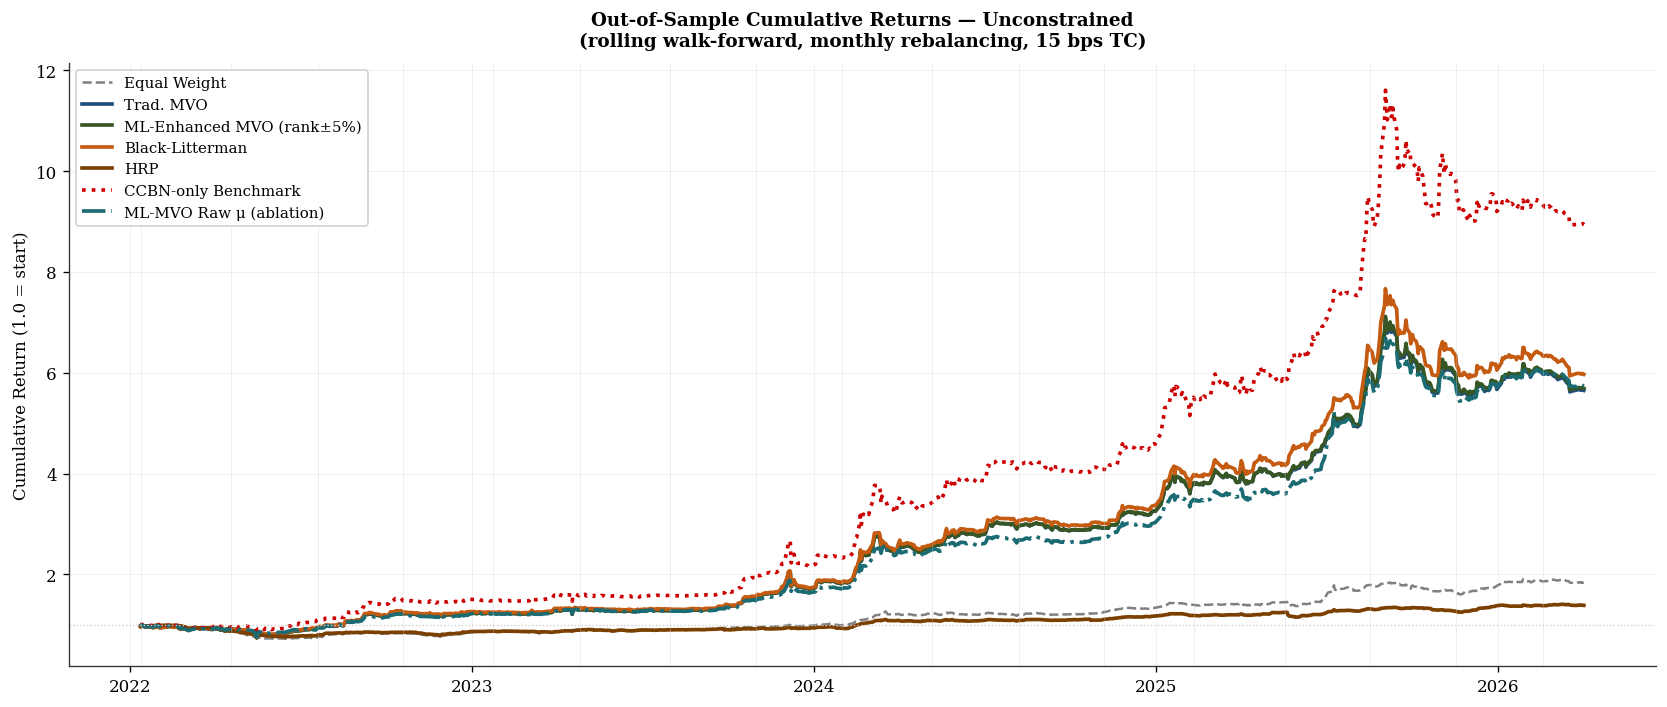

In [12]:
import matplotlib.dates as mdates

COLOR_MAP = {
    'EW':          CUSTOM_COLORS['grey'],
    'Trad_MVO':    CUSTOM_COLORS['blue'],
    'ML_MVO':      CUSTOM_COLORS['green'],
    'ML_MVO_raw':  '#1a6b72',          # добавлено
    'BL':          CUSTOM_COLORS['orange'],
    'HRP':         CUSTOM_COLORS['brown'],
    'CCBN_only':   '#cc0000',          # добавлено
}

STYLE_MAP = {
    'EW':          '--',
    'Trad_MVO':    '-',
    'ML_MVO':      '-',
    'ML_MVO_raw':  '-.',               # добавлено
    'BL':          '-',
    'HRP':         '-',
    'CCBN_only':   ':',                # добавлено
}

fig, ax = plt.subplots(figsize=(14, 6))
for col in cum_ret_df.columns:
    lw = 1.5 if col == 'EW' else 2.2
    ax.plot(cum_ret_df.index, cum_ret_df[col],
            label=LABELS[col], color=COLOR_MAP[col],
            linestyle=STYLE_MAP[col], linewidth=lw)

for rd in rebal_dates[::3]:
    ax.axvline(rd, color='#cccccc', linewidth=0.4, alpha=0.5)
ax.axhline(1.0, color='#cccccc', linewidth=0.8, linestyle=':')
ax.set_title('Out-of-Sample Cumulative Returns — Unconstrained\n'
             '(rolling walk-forward, monthly rebalancing, 15 bps TC)',
             fontweight='bold', pad=10)
ax.set_ylabel('Cumulative Return (1.0 = start)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(loc='upper left', framealpha=0.9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


### 7.2 Drawdown Analysis

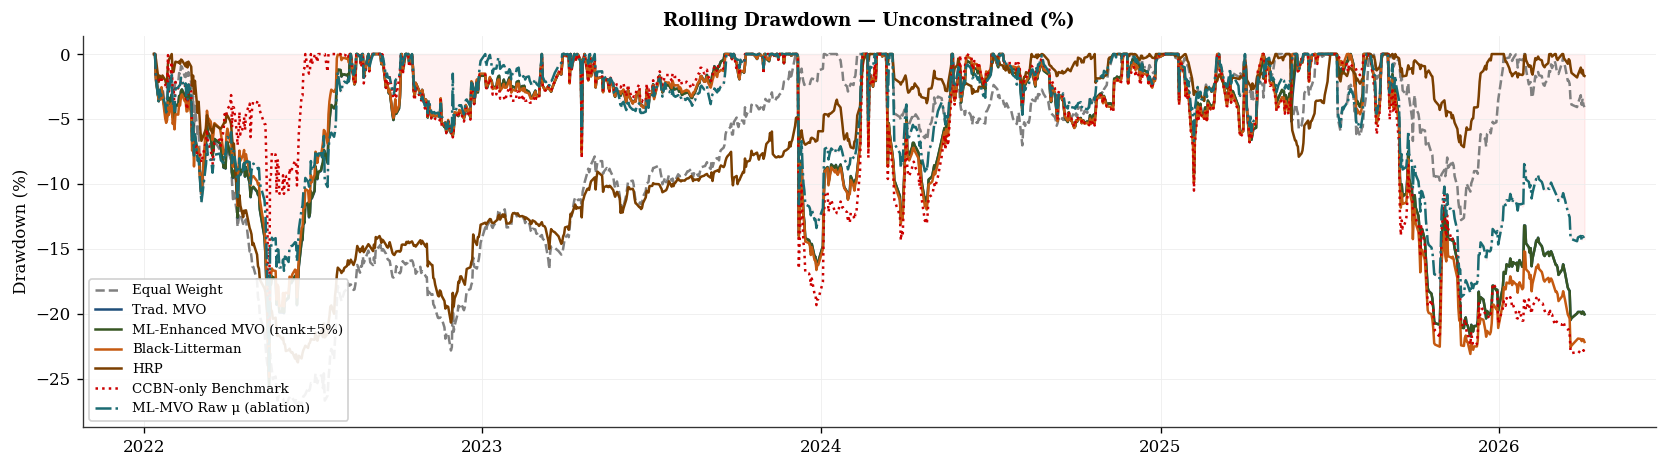

In [13]:
fig, ax = plt.subplots(figsize=(14, 4))
for col in port_ret_df.columns:
    cum = (1+port_ret_df[col]).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax() * 100
    ax.plot(dd.index, dd, label=LABELS[col],
            color=COLOR_MAP[col], linewidth=1.5, linestyle=STYLE_MAP[col])

ax.fill_between(dd.index, dd.values, 0, alpha=0.05, color='red')
ax.set_title('Rolling Drawdown — Unconstrained (%)', fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(loc='lower left', framealpha=0.9, fontsize=8)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


### 7.3 Final Rebalance Weight Allocation

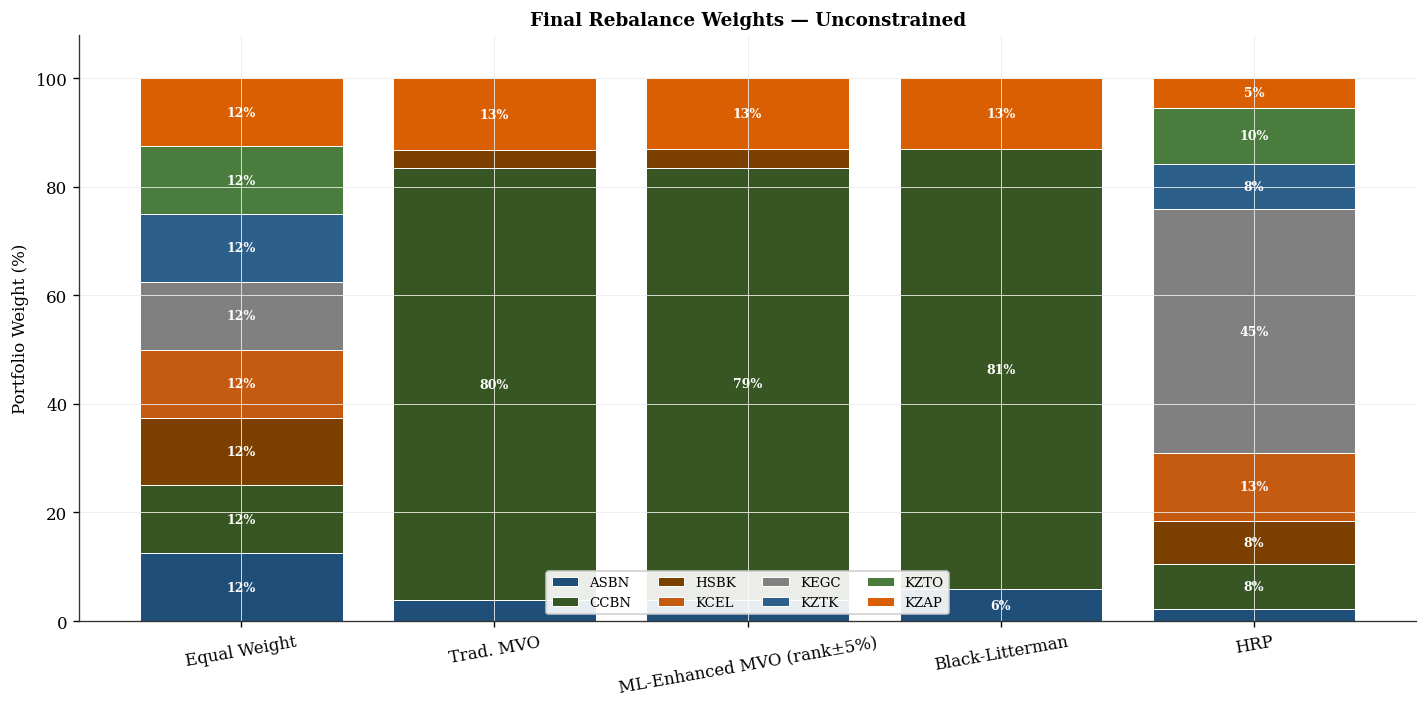

In [15]:
# Final weights from last rebalance window
train_final = ret_clean.iloc[:rebal_ix[-1]]
lw_f = LW(); lw_f.fit(train_final.values)
cov_f  = pd.DataFrame(lw_f.covariance_*TRADING_DAYS,
                      index=EQUITY_TICKERS, columns=EQUITY_TICKERS)
mu_f   = train_final.mean() * TRADING_DAYS
mu_f_t = mu_f + ml_tilt

final_w_uncap = {
    'EW':       pd.Series(1/n, index=EQUITY_TICKERS),
    'Trad_MVO': safe_mvo(mu_f,   cov_f, capped=False),
    'ML_MVO':   safe_mvo(mu_f_t, cov_f, capped=False),
    'BL':       safe_bl(mu_f_t,  cov_f, capped=False),
    'HRP':      safe_hrp(cov_f),
}

TICKER_COLORS = [
    CUSTOM_COLORS['blue'], CUSTOM_COLORS['green'], CUSTOM_COLORS['brown'],
    CUSTOM_COLORS['orange'], CUSTOM_COLORS['grey'],
    '#2c5f8a', '#4a7c3e', '#d95f02',
]

weights_df = pd.DataFrame(final_w_uncap).T * 100
CORE_STRATS_UNC = ['EW', 'Trad_MVO', 'ML_MVO', 'BL', 'HRP']
weights_df = pd.DataFrame({s: final_w_uncap[s] for s in CORE_STRATS_UNC}).T * 100
weights_df.index = [LABELS[c] for c in CORE_STRATS_UNC]

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(weights_df))
for i, ticker in enumerate(EQUITY_TICKERS):
    vals = weights_df[ticker].values
    ax.bar(weights_df.index, vals, bottom=bottom,
           label=ticker, color=TICKER_COLORS[i],
           edgecolor='white', linewidth=0.6)
    for j, (v, b) in enumerate(zip(vals, bottom)):
        if v > 5:
            ax.text(j, b+v/2, f'{v:.0f}%', ha='center', va='center',
                    fontsize=7.5, color='white', fontweight='bold')
    bottom += vals

ax.set_ylabel('Portfolio Weight (%)')
ax.set_title('Final Rebalance Weights — Unconstrained', fontweight='bold')
ax.set_ylim(0, 108)
ax.legend(loc='lower center', ncol=4, fontsize=8, framealpha=0.9)
ax.spines[['top','right']].set_visible(False)
ax.tick_params(axis='x', rotation=10)
plt.tight_layout(); plt.show()


### 7.4 Efficient Frontier with Portfolio Overlay

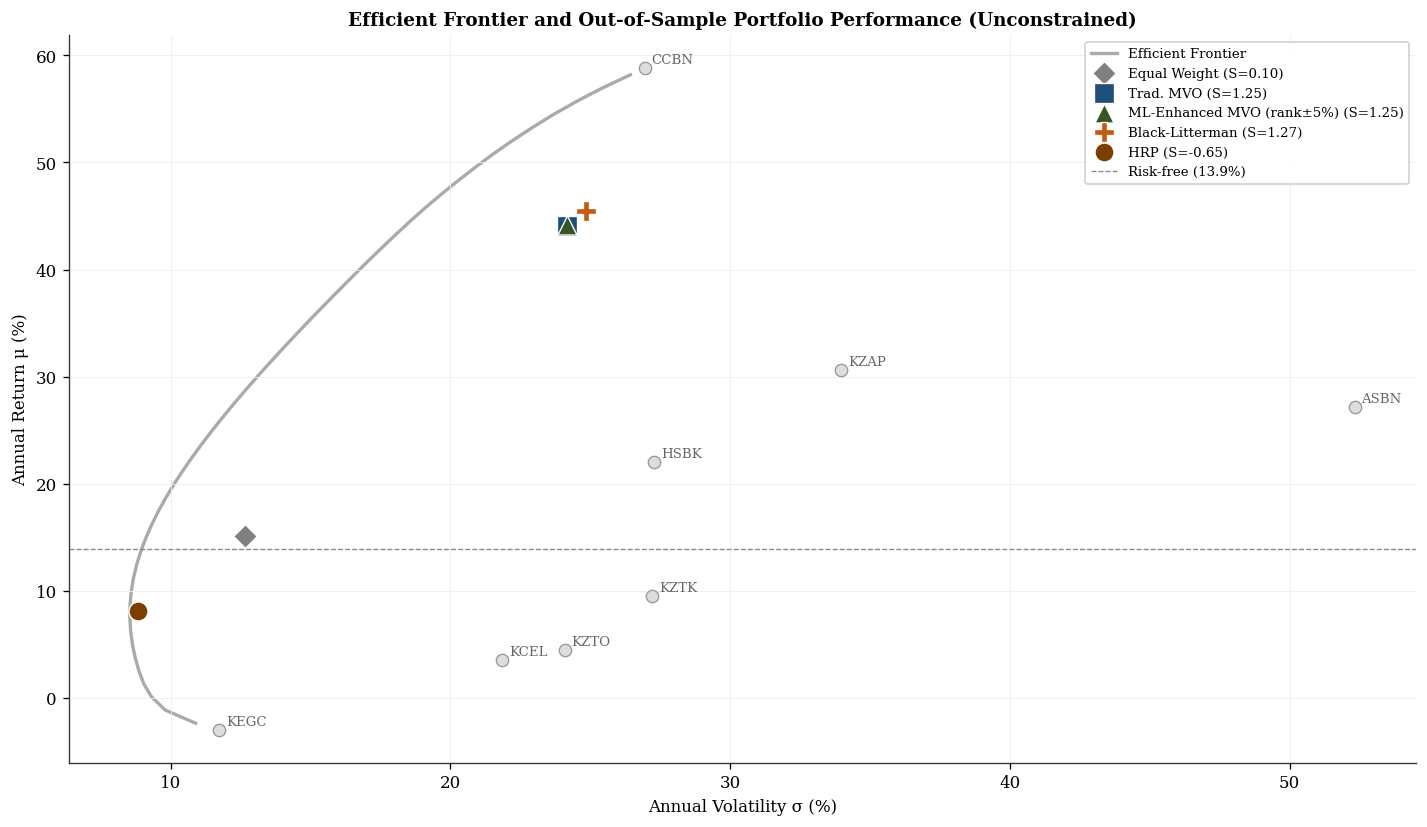

In [16]:
target_returns = np.linspace(mu_hist_annual.min()*0.8, mu_hist_annual.max()*1.2, 60)
ef_vols, ef_rets = [], []
for r_target in target_returns:
    res = minimize(lambda w: min_volatility(w, cov_annual.values),
                   np.ones(n_assets)/n_assets, method='SLSQP',
                   bounds=[(0,1)]*n_assets,
                   constraints=[
                       {'type':'eq','fun': lambda w: np.sum(w)-1},
                       {'type':'eq','fun': lambda w,r=r_target: w@mu_hist_annual.values-r}
                   ], options={'ftol':1e-12})
    if res.success:
        ef_vols.append(res.fun*100); ef_rets.append(r_target*100)

fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(ef_vols, ef_rets, '-', color='#AAAAAA', linewidth=2,
        label='Efficient Frontier', zorder=1)
for i, t in enumerate(EQUITY_TICKERS):
    ax.scatter(sigma_annual[i]*100, mu_hist_annual[t]*100,
               s=55, color='#DDDDDD', zorder=3,
               edgecolors='#999999', linewidth=0.8)
    ax.annotate(t, (sigma_annual[i]*100, mu_hist_annual[t]*100),
                xytext=(4,3), textcoords='offset points', fontsize=8, color='#666666')

overlay = [
    ('EW',       CUSTOM_COLORS['grey'],   'D', 100),
    ('Trad_MVO', CUSTOM_COLORS['blue'],   's', 130),
    ('ML_MVO',   CUSTOM_COLORS['green'],  '^', 130),
    ('BL',       CUSTOM_COLORS['orange'], 'P', 130),
    ('HRP',      CUSTOM_COLORS['brown'],  'o', 130),
]
for col, color, marker, size in overlay:
    r_s   = port_ret_df[col]
    ann_r = r_s.mean()*TRADING_DAYS*100
    ann_v = r_s.std()*np.sqrt(TRADING_DAYS)*100
    sh    = (r_s.mean()*TRADING_DAYS - RISK_FREE_RATE) / (r_s.std()*np.sqrt(TRADING_DAYS))
    ax.scatter(ann_v, ann_r, s=size, color=color, marker=marker,
               zorder=5, edgecolors='white', linewidth=0.8,
               label=f'{LABELS[col]} (S={sh:.2f})')

ax.axhline(RISK_FREE_RATE*100, color='#888888', linewidth=0.8, linestyle='--',
           label=f'Risk-free ({RISK_FREE_RATE*100:.1f}%)')
ax.set_xlabel('Annual Volatility σ (%)'); ax.set_ylabel('Annual Return μ (%)')
ax.set_title('Efficient Frontier and Out-of-Sample Portfolio Performance (Unconstrained)',
             fontweight='bold')
ax.legend(loc='best', fontsize=8, framealpha=0.9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


### 7.5 HRP Dendrogram and Weight Comparison

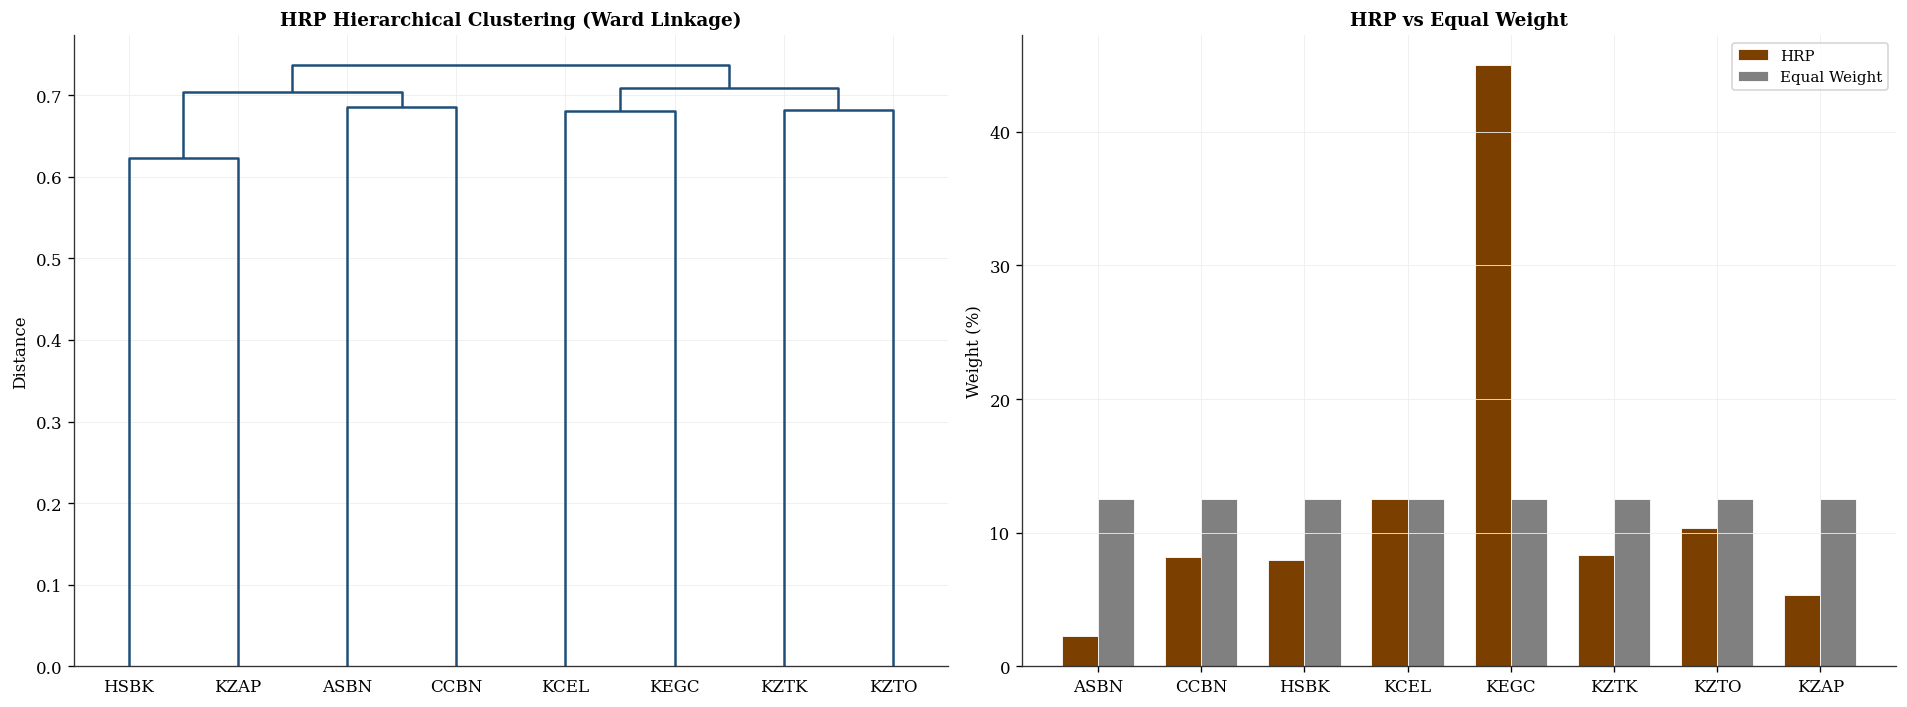

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr_hrp = ret_clean.corr()
dist_hrp = np.sqrt((1 - corr_hrp) / 2)
link_hrp = linkage(squareform(dist_hrp.values, checks=False), method='ward')

plt.sca(axes[0])
dendrogram(link_hrp, labels=EQUITY_TICKERS, leaf_rotation=0, leaf_font_size=10,
           color_threshold=0.6*max(link_hrp[:,2]), ax=axes[0],
           link_color_func=lambda k: CUSTOM_COLORS['blue'])
axes[0].set_title('HRP Hierarchical Clustering (Ward Linkage)', fontweight='bold')
axes[0].set_ylabel('Distance')
axes[0].spines[['top','right']].set_visible(False)

ax2 = axes[1]
x = np.arange(n_assets); bw = 0.35
hrp_w = final_w_uncap['HRP']
ew_w  = pd.Series(1/n, index=EQUITY_TICKERS)
ax2.bar(x-bw/2, hrp_w.values*100, bw, label='HRP',
        color=CUSTOM_COLORS['brown'], edgecolor='white', linewidth=0.5)
ax2.bar(x+bw/2, ew_w.values*100,  bw, label='Equal Weight',
        color=CUSTOM_COLORS['grey'],  edgecolor='white', linewidth=0.5)
ax2.set_xticks(x); ax2.set_xticklabels(EQUITY_TICKERS)
ax2.set_ylabel('Weight (%)'); ax2.set_title('HRP vs Equal Weight', fontweight='bold')
ax2.legend(); ax2.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


### 7.6 Performance Metrics Heatmap (Unconstrained)

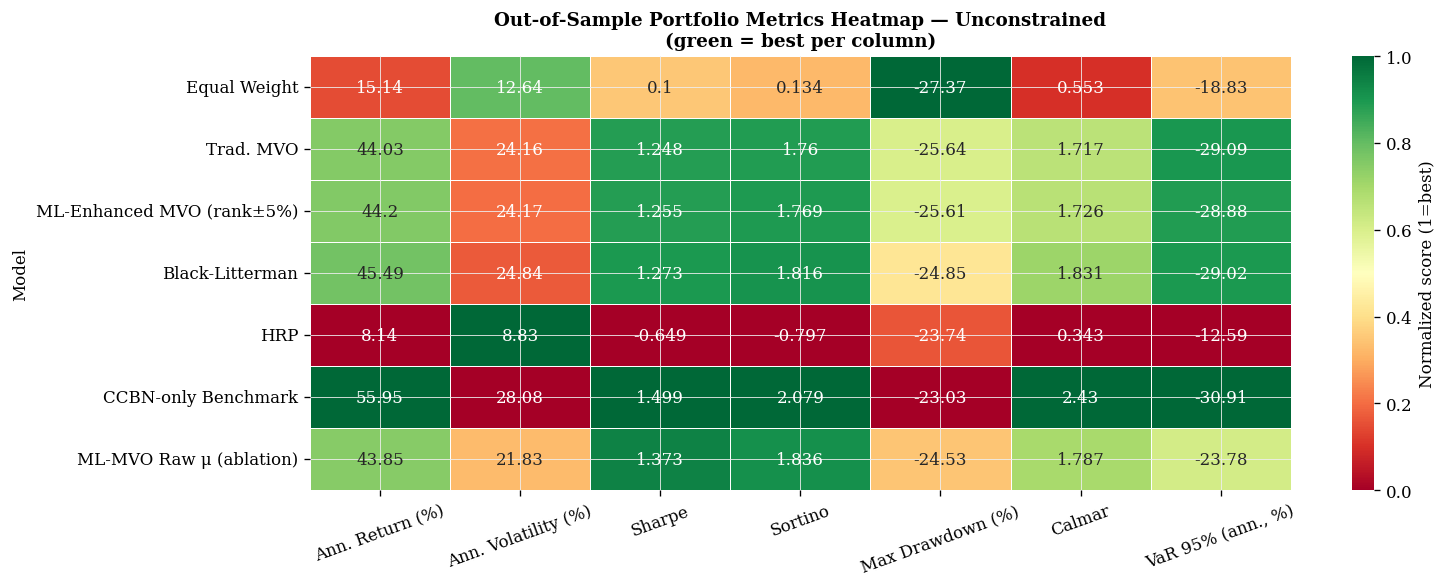

In [18]:
def plot_metrics_heatmap(df, title):
    metric_cols = ['Ann. Return (%)', 'Ann. Volatility (%)', 'Sharpe',
                   'Sortino', 'Max Drawdown (%)', 'Calmar', 'VaR 95% (ann., %)']
    hdata = df[metric_cols].copy()
    hnorm = hdata.copy().astype(float)
    good_high = ['Ann. Return (%)', 'Sharpe', 'Sortino', 'Calmar']
    good_low  = ['Ann. Volatility (%)', 'Max Drawdown (%)', 'VaR 95% (ann., %)']
    for col in good_high:
        hnorm[col] = (hdata[col]-hdata[col].min()) / (hdata[col].max()-hdata[col].min()+1e-12)
    for col in good_low:
        hnorm[col] = 1-(hdata[col]-hdata[col].min()) / (hdata[col].max()-hdata[col].min()+1e-12)
    fig, ax = plt.subplots(figsize=(13, 5))
    sns.heatmap(hnorm, annot=hdata.round(3), fmt='g',
                cmap='RdYlGn', linewidths=0.4, ax=ax,
                cbar_kws={'label':'Normalized score (1=best)'},
                vmin=0, vmax=1)
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    plt.tight_layout(); plt.show()

plot_metrics_heatmap(eval_df,
    'Out-of-Sample Portfolio Metrics Heatmap — Unconstrained\n(green = best per column)')


### 7.7 Return Forecast Comparison: Historical vs ML vs BL

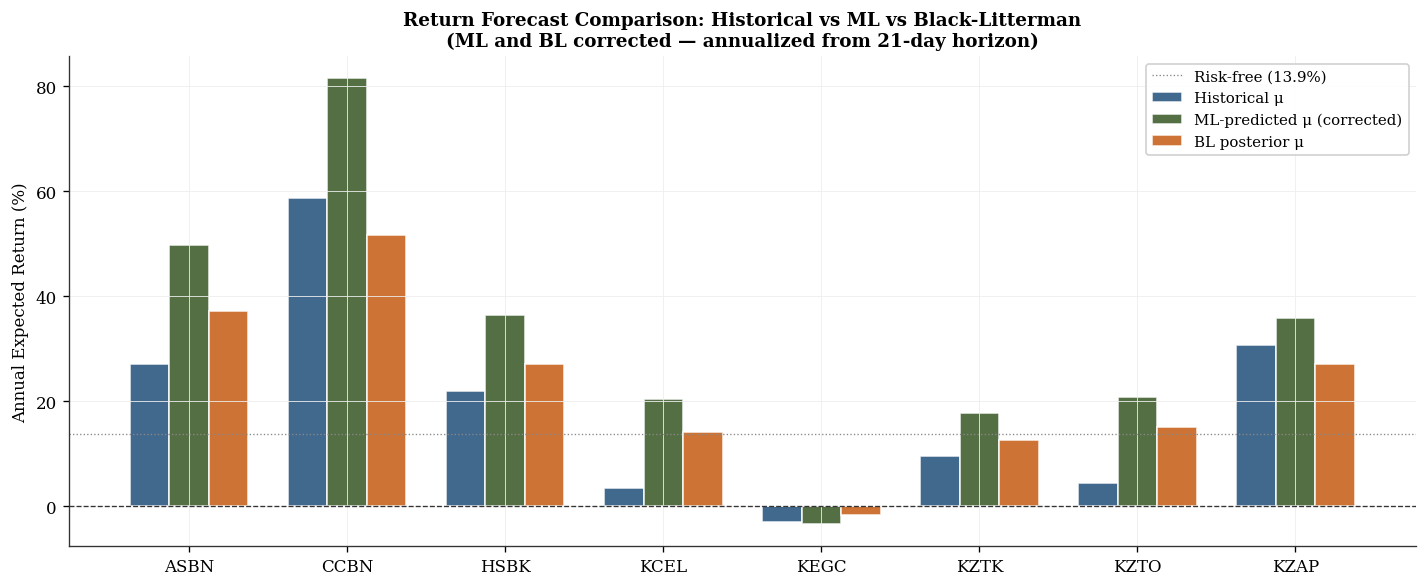

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(n_assets); bw = 0.25

ax.bar(x-bw,  mu_hist_annual.values*100, bw, label='Historical μ',
       color=CUSTOM_COLORS['blue'],   alpha=0.85, edgecolor='white')
ax.bar(x,     mu_ml_annual.values*100,  bw, label='ML-predicted μ (corrected)',
       color=CUSTOM_COLORS['green'],  alpha=0.85, edgecolor='white')
ax.bar(x+bw,  mu_bl.values*100,         bw, label='BL posterior μ',
       color=CUSTOM_COLORS['orange'], alpha=0.85, edgecolor='white')

ax.axhline(0, color='#333333', linewidth=0.8, linestyle='--')
ax.axhline(RISK_FREE_RATE*100, color='#888888', linewidth=0.8, linestyle=':',
           label=f'Risk-free ({RISK_FREE_RATE*100:.1f}%)')
ax.set_xticks(x); ax.set_xticklabels(EQUITY_TICKERS)
ax.set_ylabel('Annual Expected Return (%)')
ax.set_title('Return Forecast Comparison: Historical vs ML vs Black-Litterman\n'
             '(ML and BL corrected — annualized from 21-day horizon)',
             fontweight='bold')
ax.legend(framealpha=0.9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


## 8. Weight-Cap Sensitivity Analysis (40% Maximum per Asset)

**Motivation:**  
In the unconstrained backtest, the MVO-based strategies concentrate 58–79% in CCBN  
at many rebalancing dates (CCBN has the highest historical return on KASE over the  
sample period). While mathematically optimal given the inputs, such concentration is:
- Practically unrealistic for any institutional or retail investor
- Sensitive to estimation error in a single stock's return
- Potentially a source of hidden liquidity risk on a small exchange like KASE

**Method:**  
Re-run the identical rolling walk-forward backtest with one change:  
MVO and BL weights are bounded to `[0, 0.40]` per asset (`run_mvo_capped`).  
HRP and EW are unchanged (HRP has no concentration in the MVO stocks anyway).

**Research question:**  
Does imposing a 40% cap improve diversification and risk-adjusted performance,  
or does it sacrifice return without meaningful risk reduction?


In [20]:
STRATEGIES_CAP = ['EW', 'Trad_MVO_40', 'ML_MVO_40', 'BL_40', 'HRP']
LABELS_CAP = {
    'EW':          'Equal Weight',
    'Trad_MVO_40': 'Trad. MVO (40% cap)',
    'ML_MVO_40':   'ML-MVO (40% cap)',
    'BL_40':       'BL (40% cap)',
    'HRP':         'HRP',
}

port_returns_cap = {s: [] for s in STRATEGIES_CAP}
port_dates_cap   = []
current_w_cap    = {s: pd.Series(1/n, index=EQUITY_TICKERS) for s in STRATEGIES_CAP}
rebal_dates_cap  = []

for day_i in range(TRAIN_MIN, n_days):
    date_i = idx_arr[day_i]

    if day_i in rebal_set:
        train  = ret_clean.iloc[:day_i]
        lw_    = LW(); lw_.fit(train.values)
        cov_a  = pd.DataFrame(lw_.covariance_ * TRADING_DAYS,
                              index=EQUITY_TICKERS, columns=EQUITY_TICKERS)
        mu_h   = train.mean() * TRADING_DAYS
        mu_tlt = mu_h + ml_tilt

        new_w = {
            'EW':          pd.Series(1/n, index=EQUITY_TICKERS),
            'Trad_MVO_40': safe_mvo(mu_h,   cov_a, capped=True),
            'ML_MVO_40':   safe_mvo(mu_tlt, cov_a, capped=True),
            'BL_40':       safe_bl(mu_tlt,  cov_a, capped=True),
            'HRP':         safe_hrp(cov_a),
        }
        current_w_cap = new_w
        rebal_dates_cap.append(date_i)

    day_ret = ret_clean.iloc[day_i]
    for s in STRATEGIES_CAP:
        r = current_w_cap[s].values @ day_ret.values
        if date_i in rebal_dates_cap and len(port_returns_cap[s]) > 0:
            r -= TC_BPS
        port_returns_cap[s].append(r)
    port_dates_cap.append(date_i)

port_ret_cap = pd.DataFrame(port_returns_cap, index=port_dates_cap)
cum_ret_cap  = (1 + port_ret_cap).cumprod()

print(f'Walk-forward backtest (40% cap) complete.')
print(f'  Out-of-sample period : {port_dates_cap[0].date()} -> {port_dates_cap[-1].date()}')
print(f'  Days                 : {len(port_dates_cap)}')
print(f'  Rebalances           : {len(rebal_dates_cap)}')
print()
print('Final cumulative returns (40% capped):')
for col in cum_ret_cap.columns:
    val = cum_ret_cap[col].iloc[-1]
    print(f'  {LABELS_CAP[col]:25s}: {val:.4f}  ({(val-1)*100:+.1f}%)')


Walk-forward backtest (40% cap) complete.
  Out-of-sample period : 2022-01-12 -> 2026-04-03
  Days                 : 1037
  Rebalances           : 50

Final cumulative returns (40% capped):
  Equal Weight             : 1.8301  (+83.0%)
  Trad. MVO (40% cap)      : 2.7099  (+171.0%)
  ML-MVO (40% cap)         : 2.7240  (+172.4%)
  BL (40% cap)             : 2.8672  (+186.7%)
  HRP                      : 1.3863  (+38.6%)


### 8.1 Weight-Capped Performance Metrics

In [21]:
eval_cap = build_metrics_df(port_ret_cap, LABELS_CAP)

print('OUT-OF-SAMPLE METRICS — 40% WEIGHT-CAPPED PORTFOLIOS')
print('='*92)
print(eval_cap.to_string())
print()
print(f"Best Sharpe   : {eval_cap['Sharpe'].idxmax()} ({eval_cap['Sharpe'].max():.4f})")
print(f"Best Sortino  : {eval_cap['Sortino'].idxmax()} ({eval_cap['Sortino'].max():.4f})")
print(f"Lowest vol    : {eval_cap['Ann. Volatility (%)'].idxmin()} ({eval_cap['Ann. Volatility (%)'].min():.2f}%)")
print(f"Highest return: {eval_cap['Ann. Return (%)'].idxmax()} ({eval_cap['Ann. Return (%)'].max():.2f}%)")


OUT-OF-SAMPLE METRICS — 40% WEIGHT-CAPPED PORTFOLIOS
                     Ann. Return (%)  Ann. Volatility (%)  Sharpe  Sortino  Max Drawdown (%)  Calmar  VaR 95% (ann., %)
Model                                                                                                                  
Equal Weight                   15.14                12.64  0.1003   0.1338            -27.37  0.5531             -18.83
Trad. MVO (40% cap)            25.40                18.63  0.6190   0.7810            -26.50  0.9588             -25.60
ML-MVO (40% cap)               25.53                18.67  0.6246   0.7903            -26.56  0.9612             -25.67
BL (40% cap)                   26.92                19.61  0.6657   0.8931            -28.06  0.9594             -27.96
HRP                             8.14                 8.83 -0.6490  -0.7973            -23.74  0.3430             -12.59

Best Sharpe   : BL (40% cap) (0.6657)
Best Sortino  : BL (40% cap) (0.8931)
Lowest vol    : HRP (8.83%)
Hi

### 8.2 Unconstrained vs 40%-Capped: Direct Comparison

In [22]:
# Map unconstrained strategies to their capped counterparts for comparison
PAIR_MAP = {
    'Trad_MVO':   'Trad_MVO_40',
    'ML_MVO':     'ML_MVO_40',
    'BL':         'BL_40',
}
UNCAP_LABELS = {'Trad_MVO':'Trad. MVO','ML_MVO':'ML-MVO','BL':'Black-Litterman'}

compare_rows = []
for unc, cap in PAIR_MAP.items():
    for col, variant, suffix in [(unc, port_ret_df, 'Unconstrained'),
                                 (cap, port_ret_cap, '40% Cap')]:
        r      = variant[col]
        ann_r  = r.mean() * TRADING_DAYS
        ann_v  = r.std()  * np.sqrt(TRADING_DAYS)
        sh     = (ann_r - RISK_FREE_RATE) / ann_v if ann_v > 1e-10 else 0.0
        compare_rows.append({
            'Strategy': UNCAP_LABELS[unc],
            'Variant':  suffix,
            'Ann. Return (%)':     round(ann_r*100, 2),
            'Ann. Volatility (%)': round(ann_v*100, 2),
            'Sharpe':              round(sh, 4),
            'Sortino':             round(sortino(r), 4),
            'Max Drawdown (%)':    round(max_dd(r)*100, 2),
        })

compare_df = pd.DataFrame(compare_rows).set_index(['Strategy','Variant'])
print('UNCONSTRAINED vs 40% WEIGHT-CAPPED — DIRECT COMPARISON')
print('='*80)
print(compare_df.to_string())
print()

# Compute delta (Cap - Unconstrained) for key metrics
print('DELTA (40% Cap minus Unconstrained):')
print('-'*60)
for strategy in UNCAP_LABELS.values():
    d_ret = (compare_df.loc[(strategy,'40% Cap'),'Ann. Return (%)']
             - compare_df.loc[(strategy,'Unconstrained'),'Ann. Return (%)'])
    d_vol = (compare_df.loc[(strategy,'40% Cap'),'Ann. Volatility (%)']
             - compare_df.loc[(strategy,'Unconstrained'),'Ann. Volatility (%)'])
    d_sh  = (compare_df.loc[(strategy,'40% Cap'),'Sharpe']
             - compare_df.loc[(strategy,'Unconstrained'),'Sharpe'])
    d_dd  = (compare_df.loc[(strategy,'40% Cap'),'Max Drawdown (%)']
             - compare_df.loc[(strategy,'Unconstrained'),'Max Drawdown (%)'])
    print(f'  {strategy:20s}:  ΔReturn={d_ret:+.2f}%  ΔVol={d_vol:+.2f}%  '
          f'ΔSharpe={d_sh:+.4f}  ΔMaxDD={d_dd:+.2f}%')


UNCONSTRAINED vs 40% WEIGHT-CAPPED — DIRECT COMPARISON
                               Ann. Return (%)  Ann. Volatility (%)  Sharpe  Sortino  Max Drawdown (%)
Strategy        Variant                                                                               
Trad. MVO       Unconstrained            44.03                24.16  1.2482   1.7597            -25.64
                40% Cap                  25.40                18.63  0.6190   0.7810            -26.50
ML-MVO          Unconstrained            44.20                24.17  1.2549   1.7688            -25.61
                40% Cap                  25.53                18.67  0.6246   0.7903            -26.56
Black-Litterman Unconstrained            45.49                24.84  1.2732   1.8163            -24.85
                40% Cap                  26.92                19.61  0.6657   0.8931            -28.06

DELTA (40% Cap minus Unconstrained):
------------------------------------------------------------
  Trad. MVO           

### 8.3 Cumulative Return Comparison: Unconstrained vs 40% Cap

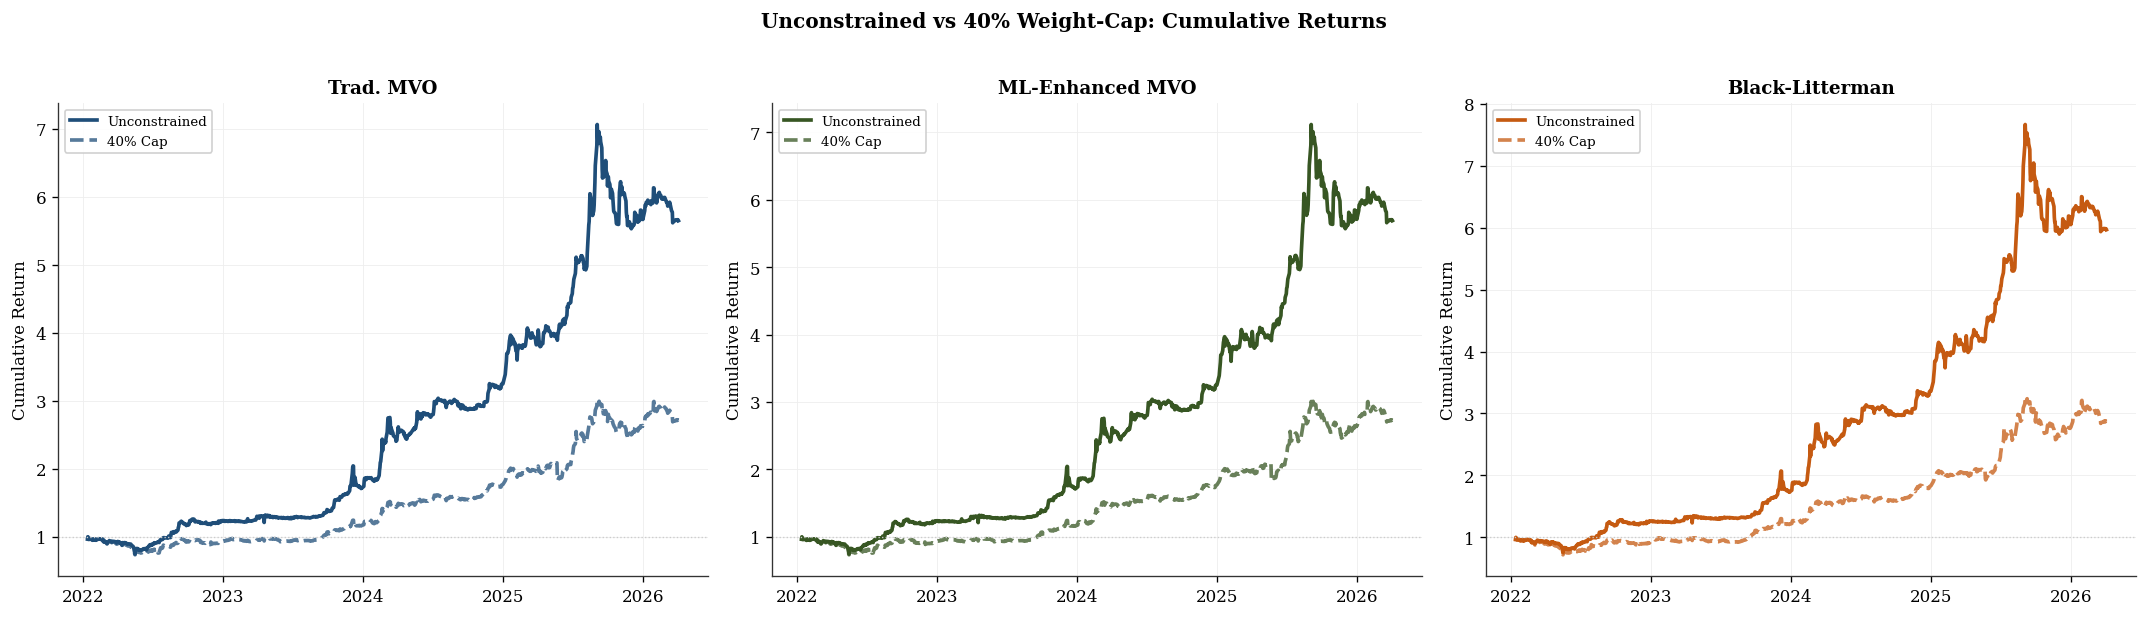

In [23]:
COLOR_CAP = {
    'EW':          CUSTOM_COLORS['grey'],
    'Trad_MVO_40': CUSTOM_COLORS['blue'],
    'ML_MVO_40':   CUSTOM_COLORS['green'],
    'BL_40':       CUSTOM_COLORS['orange'],
    'HRP':         CUSTOM_COLORS['brown'],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
PAIRS = [
    ('Trad_MVO', 'Trad_MVO_40', 'Trad. MVO', CUSTOM_COLORS['blue']),
    ('ML_MVO',   'ML_MVO_40',   'ML-Enhanced MVO', CUSTOM_COLORS['green']),
    ('BL',       'BL_40',       'Black-Litterman', CUSTOM_COLORS['orange']),
]

for ax, (unc, cap, title, color) in zip(axes, PAIRS):
    ax.plot(cum_ret_df.index, cum_ret_df[unc],
            label='Unconstrained', color=color, linewidth=2.2, linestyle='-')
    ax.plot(cum_ret_cap.index, cum_ret_cap[cap],
            label='40% Cap', color=color, linewidth=2.2, linestyle='--', alpha=0.75)
    ax.axhline(1.0, color='#cccccc', linewidth=0.8, linestyle=':')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Cumulative Return')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.legend(fontsize=8, framealpha=0.9)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Unconstrained vs 40% Weight-Cap: Cumulative Returns',
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


### 8.4 Weight Evolution: CCBN Allocation Over Time (Unconstrained vs Capped)

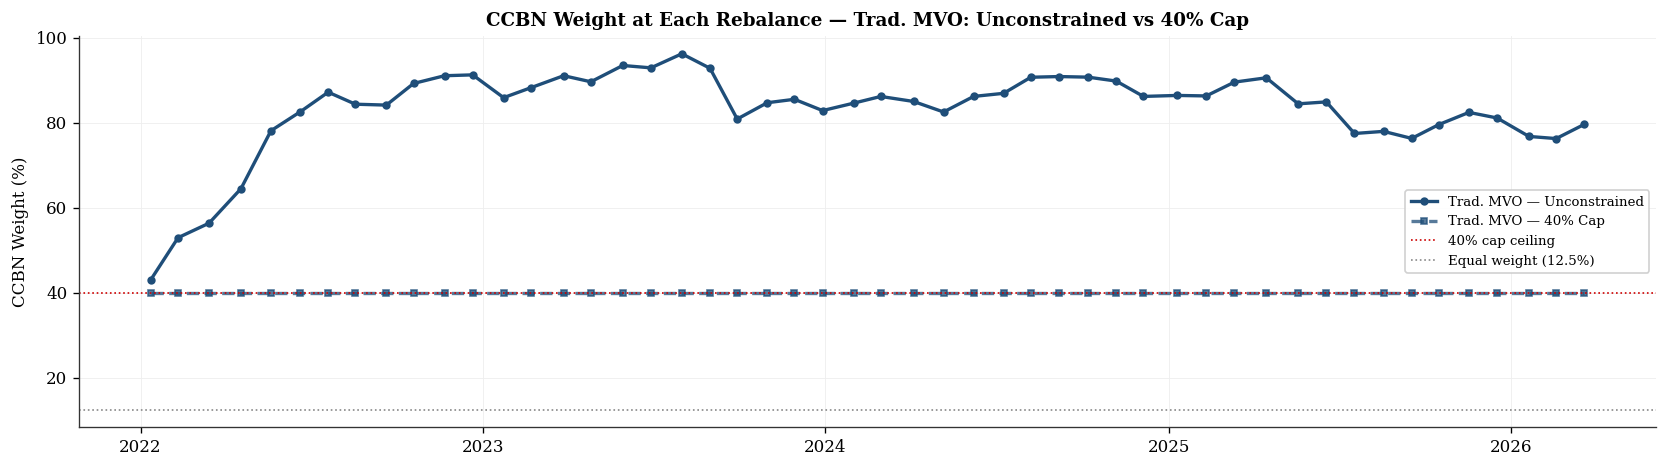

Average CCBN weight across rebalances:
  Unconstrained: 83.1%
  40% capped   : 40.0%
  Reduction    : 43.1 percentage points


In [24]:
# Reconstruct CCBN weight at each rebalance for Trad_MVO uncap vs capped
ccbn_weights_unc = []
ccbn_weights_cap = []
rebal_plot_dates = []

for day_i in rebal_ix:
    train  = ret_clean.iloc[:day_i]
    lw_    = LW(); lw_.fit(train.values)
    cov_a  = pd.DataFrame(lw_.covariance_*TRADING_DAYS,
                          index=EQUITY_TICKERS, columns=EQUITY_TICKERS)
    mu_h   = train.mean() * TRADING_DAYS
    w_unc  = safe_mvo(mu_h, cov_a, capped=False)
    w_cap  = safe_mvo(mu_h, cov_a, capped=True)
    ccbn_weights_unc.append(w_unc['CCBN'])
    ccbn_weights_cap.append(w_cap['CCBN'])
    rebal_plot_dates.append(idx_arr[day_i])

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(rebal_plot_dates, [w*100 for w in ccbn_weights_unc],
        label='Trad. MVO — Unconstrained', color=CUSTOM_COLORS['blue'],
        linewidth=2, marker='o', markersize=4)
ax.plot(rebal_plot_dates, [w*100 for w in ccbn_weights_cap],
        label='Trad. MVO — 40% Cap', color=CUSTOM_COLORS['blue'],
        linewidth=2, marker='s', markersize=4, linestyle='--', alpha=0.75)
ax.axhline(40, color='#cc0000', linewidth=1, linestyle=':', label='40% cap ceiling')
ax.axhline(100/n_assets, color='#888888', linewidth=1,
           linestyle=':', label=f'Equal weight ({100/n_assets:.1f}%)')
ax.set_ylabel('CCBN Weight (%)')
ax.set_title('CCBN Weight at Each Rebalance — Trad. MVO: Unconstrained vs 40% Cap',
             fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(fontsize=8, framealpha=0.9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

avg_unc = np.mean(ccbn_weights_unc)*100
avg_cap = np.mean(ccbn_weights_cap)*100
print(f'Average CCBN weight across rebalances:')
print(f'  Unconstrained: {avg_unc:.1f}%')
print(f'  40% capped   : {avg_cap:.1f}%')
print(f'  Reduction    : {avg_unc - avg_cap:.1f} percentage points')


### 8.5 Final Weight Allocation — 40% Capped

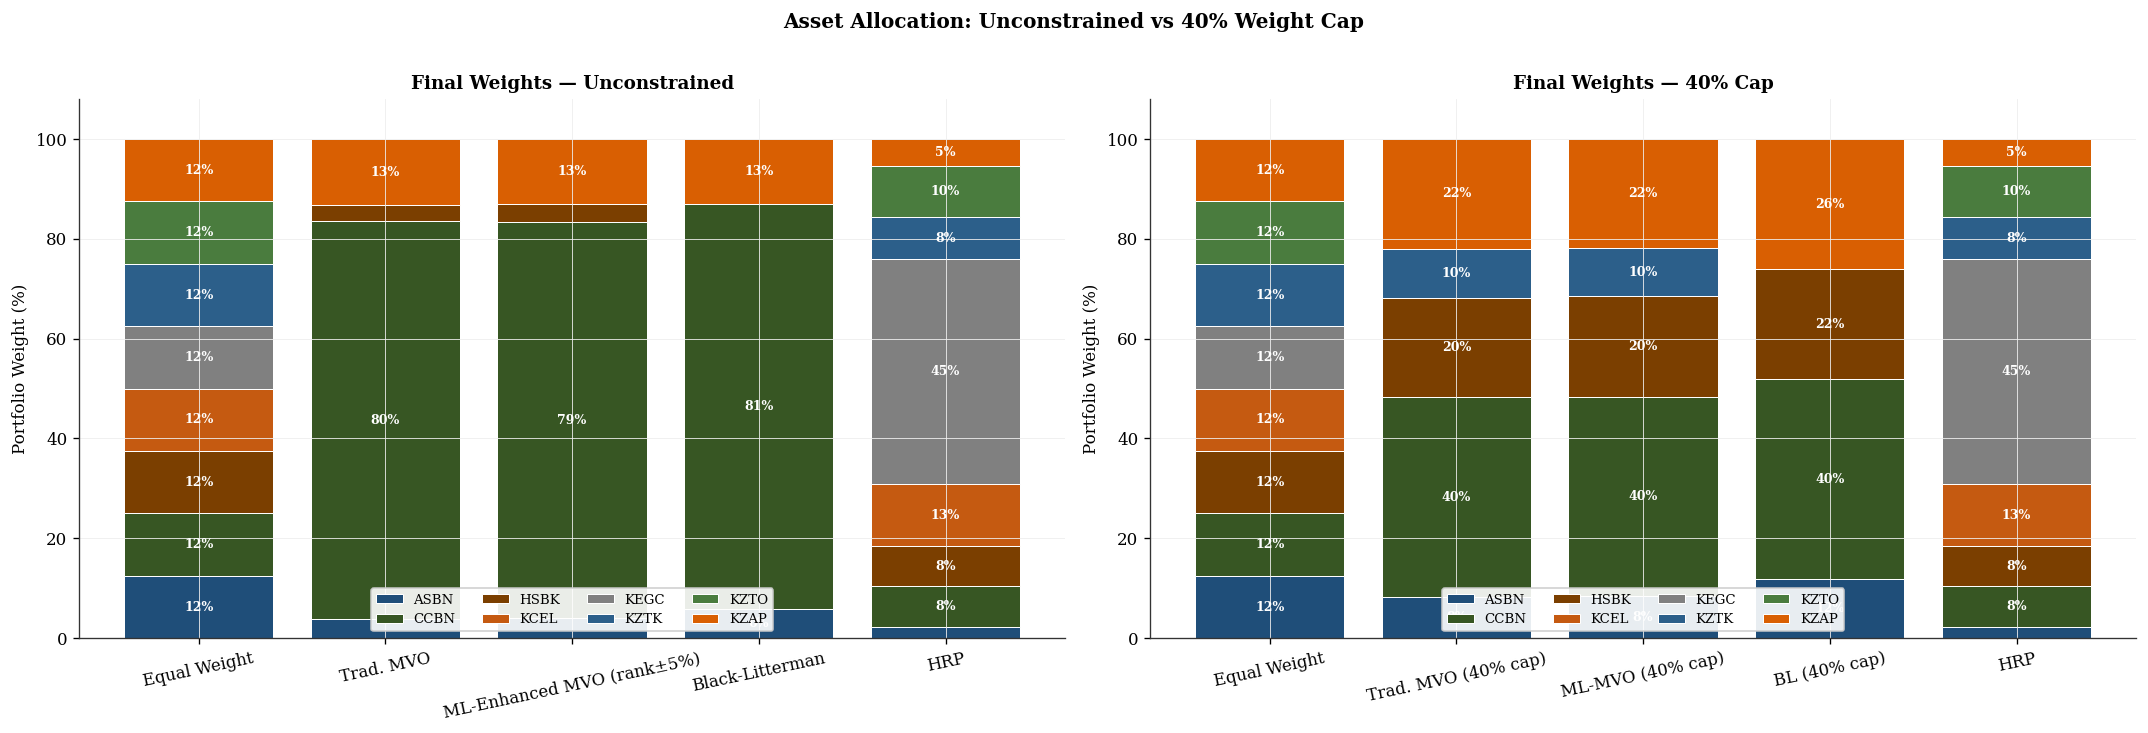

In [25]:
final_w_cap = {
    'EW':          pd.Series(1/n, index=EQUITY_TICKERS),
    'Trad_MVO_40': safe_mvo(mu_f,   cov_f, capped=True),
    'ML_MVO_40':   safe_mvo(mu_f_t, cov_f, capped=True),
    'BL_40':       safe_bl(mu_f_t,  cov_f, capped=True),
    'HRP':         safe_hrp(cov_f),
}

weights_cap_df = pd.DataFrame(final_w_cap).T * 100
weights_cap_df.index = [LABELS_CAP[c] for c in STRATEGIES_CAP]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, (wdf, title) in zip(axes, [
    (pd.DataFrame(final_w_uncap).T*100, 'Final Weights — Unconstrained'),
    (weights_cap_df,                    'Final Weights — 40% Cap'),
]):
    if title.endswith('Cap'):
        wdf.index = [LABELS_CAP[c] for c in STRATEGIES_CAP if c in wdf.index or True][:len(wdf)]
    else:
        wdf.index = [LABELS[c] for c in STRATEGIES_UNCAP if c in final_w_uncap][:len(wdf)]
    bottom = np.zeros(len(wdf))
    for i, ticker in enumerate(EQUITY_TICKERS):
        vals = wdf[ticker].values
        ax.bar(wdf.index, vals, bottom=bottom,
               label=ticker, color=TICKER_COLORS[i],
               edgecolor='white', linewidth=0.6)
        for j, (v, b) in enumerate(zip(vals, bottom)):
            if v > 4:
                ax.text(j, b+v/2, f'{v:.0f}%', ha='center', va='center',
                        fontsize=7.5, color='white', fontweight='bold')
        bottom += vals
    ax.set_ylabel('Portfolio Weight (%)'); ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 108)
    ax.legend(loc='lower center', ncol=4, fontsize=8, framealpha=0.9)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='x', rotation=12)

plt.suptitle('Asset Allocation: Unconstrained vs 40% Weight Cap', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


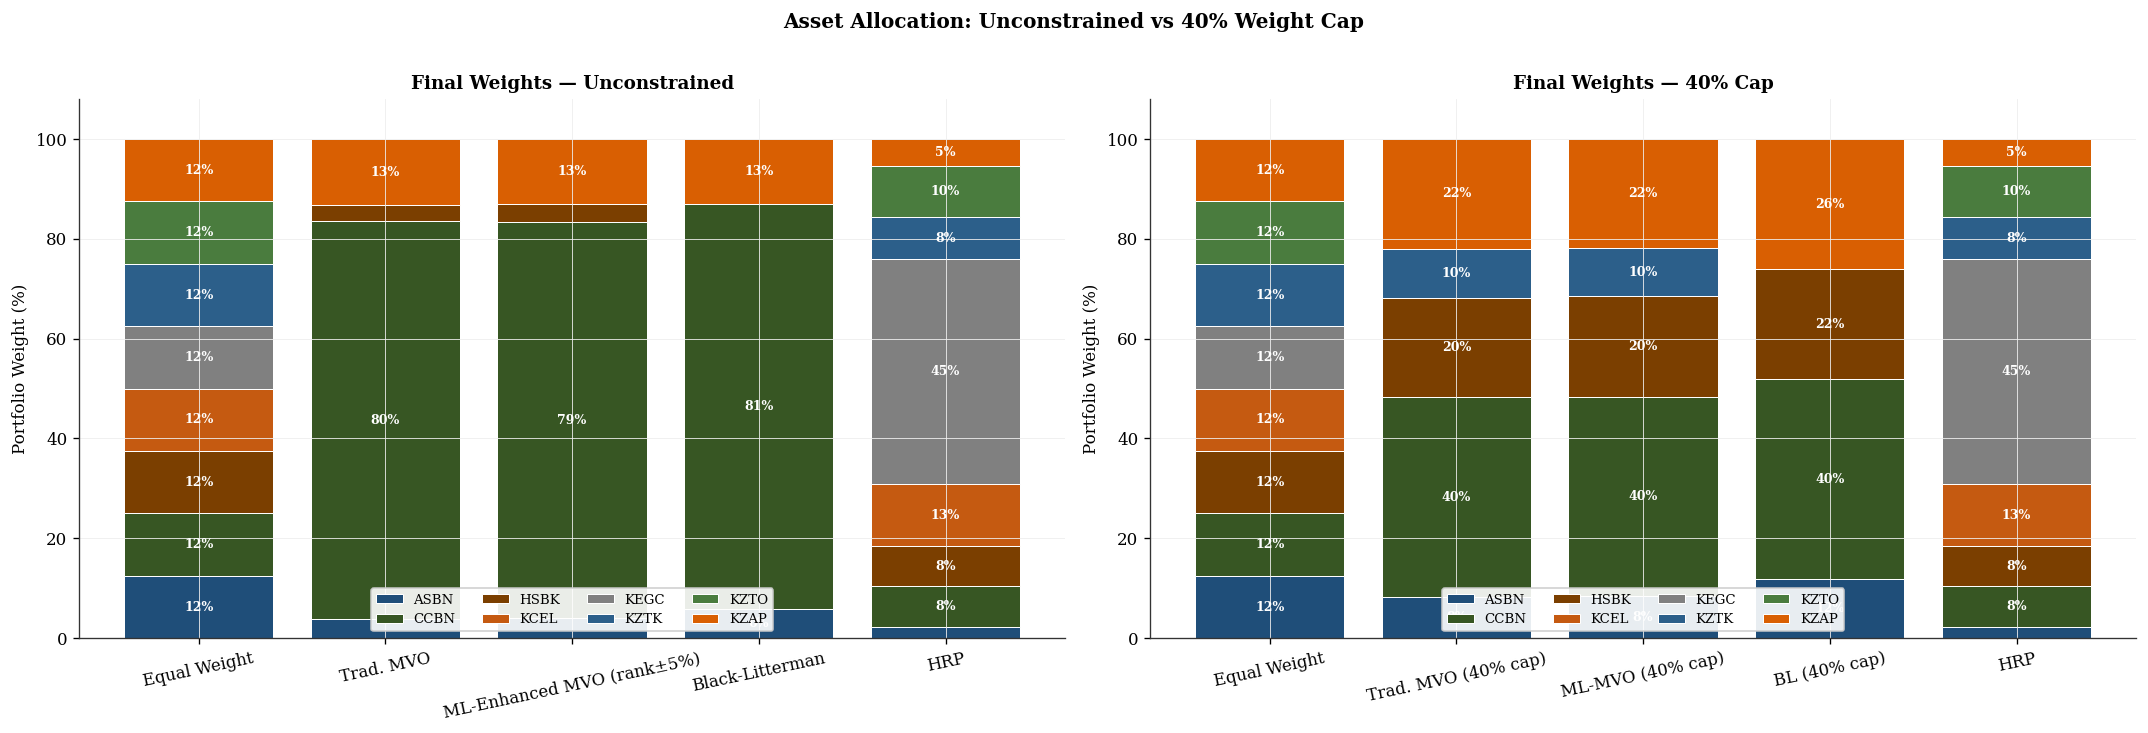

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Only plot the 5 core strategies (exclude ablation/benchmark from weight chart)
PLOT_STRATS_UNC = ['EW', 'Trad_MVO', 'ML_MVO', 'BL', 'HRP']
PLOT_STRATS_CAP = ['EW', 'Trad_MVO_40', 'ML_MVO_40', 'BL_40', 'HRP']

for ax, (strats, w_dict, labels_dict, title) in zip(axes, [
    (PLOT_STRATS_UNC, final_w_uncap, LABELS,     'Final Weights — Unconstrained'),
    (PLOT_STRATS_CAP, final_w_cap,   LABELS_CAP, 'Final Weights — 40% Cap'),
]):
    wdf = pd.DataFrame({s: w_dict[s] for s in strats if s in w_dict}).T * 100
    wdf.index = [labels_dict[s] for s in strats if s in w_dict]
    bottom = np.zeros(len(wdf))
    for i, ticker in enumerate(EQUITY_TICKERS):
        vals = wdf[ticker].values
        ax.bar(wdf.index, vals, bottom=bottom,
               label=ticker, color=TICKER_COLORS[i],
               edgecolor='white', linewidth=0.6)
        for j, (v, b) in enumerate(zip(vals, bottom)):
            if v > 4:
                ax.text(j, b+v/2, f'{v:.0f}%', ha='center', va='center',
                        fontsize=7.5, color='white', fontweight='bold')
        bottom += vals
    ax.set_ylabel('Portfolio Weight (%)')
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 108)
    ax.legend(loc='lower center', ncol=4, fontsize=8, framealpha=0.9)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='x', rotation=12)

plt.suptitle('Asset Allocation: Unconstrained vs 40% Weight Cap', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 8.6 Metrics Heatmap — 40% Capped

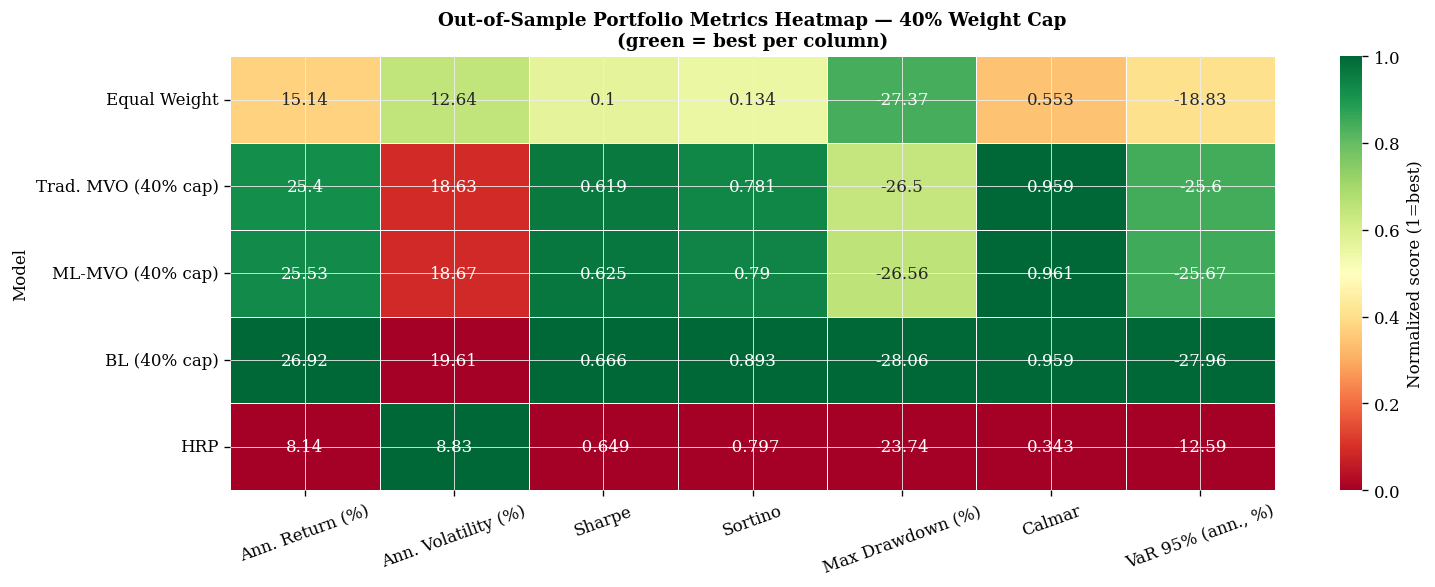

In [27]:
plot_metrics_heatmap(eval_cap,
    'Out-of-Sample Portfolio Metrics Heatmap — 40% Weight Cap\n(green = best per column)')


### 8.7 Side-by-Side Sharpe and Return Comparison (Bar Chart)

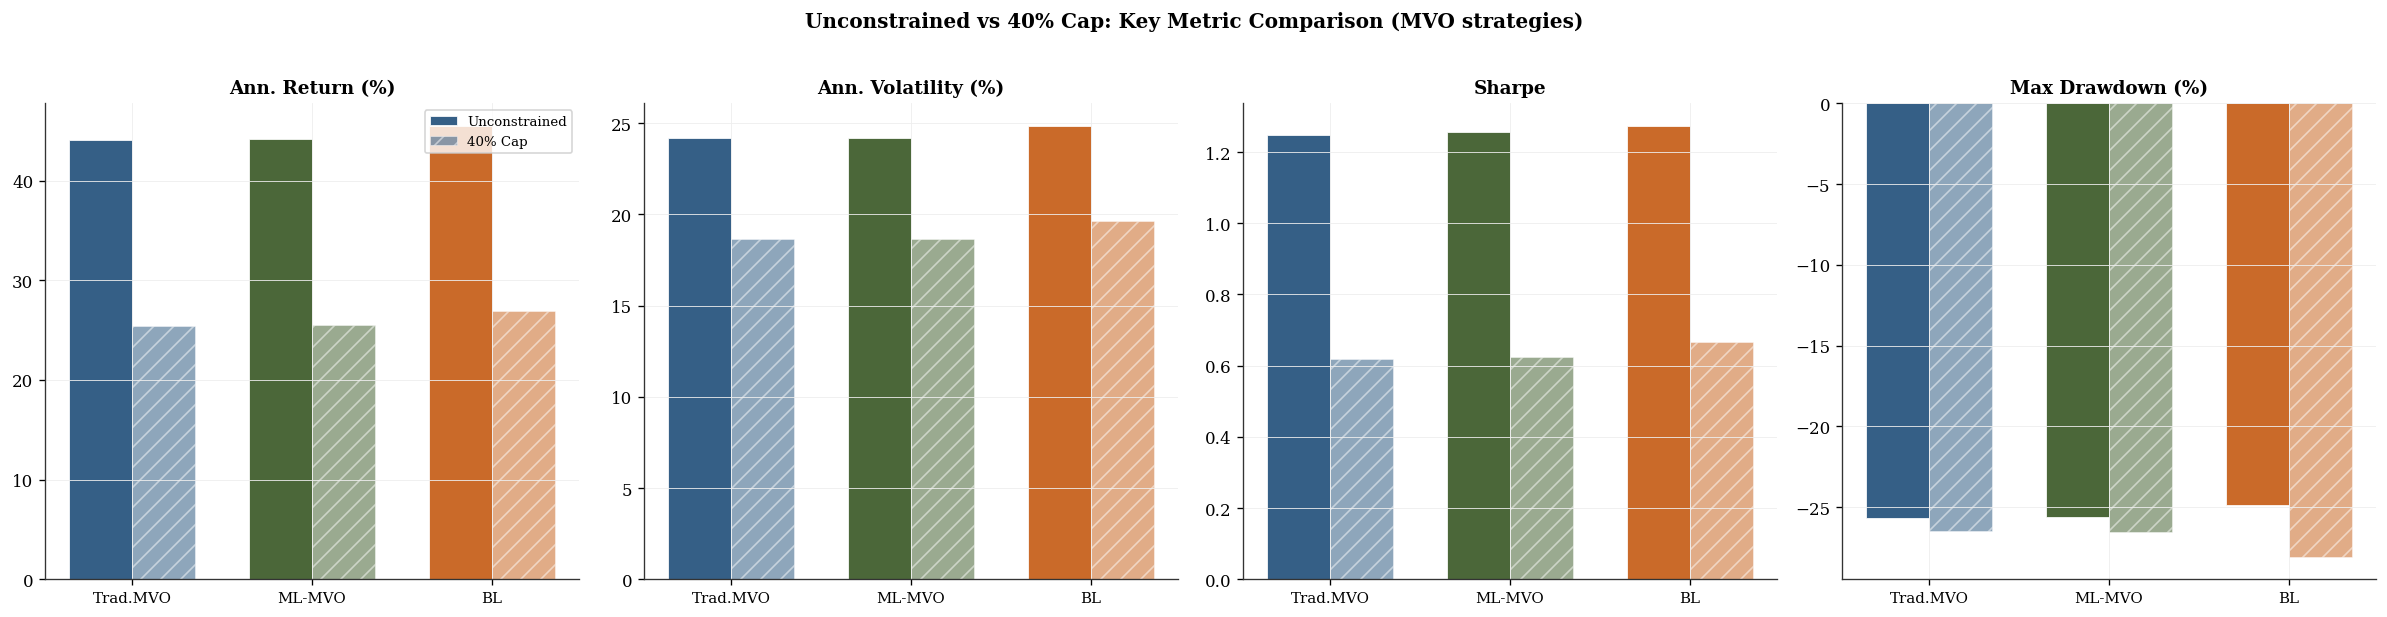

In [28]:
metrics_compare = ['Ann. Return (%)', 'Ann. Volatility (%)', 'Sharpe', 'Max Drawdown (%)']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

strategies_unc_ordered = ['Trad_MVO', 'ML_MVO', 'BL']
strategies_cap_ordered = ['Trad_MVO_40', 'ML_MVO_40', 'BL_40']
x = np.arange(len(strategies_unc_ordered))
bw = 0.35
colors_unc = [CUSTOM_COLORS['blue'], CUSTOM_COLORS['green'], CUSTOM_COLORS['orange']]

for ax, metric in zip(axes, metrics_compare):
    vals_unc = [eval_df.loc[LABELS[s], metric]     for s in strategies_unc_ordered]
    vals_cap = [eval_cap.loc[LABELS_CAP[s], metric] for s in strategies_cap_ordered]

    bars1 = ax.bar(x - bw/2, vals_unc, bw, label='Unconstrained',
                   color=colors_unc, edgecolor='white', linewidth=0.5, alpha=0.9)
    bars2 = ax.bar(x + bw/2, vals_cap, bw, label='40% Cap',
                   color=colors_unc, edgecolor='white', linewidth=0.5, alpha=0.5,
                   hatch='//')

    ax.set_xticks(x)
    ax.set_xticklabels(['Trad.MVO', 'ML-MVO', 'BL'], fontsize=9)
    ax.set_title(metric, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    if metric == metrics_compare[0]:
        ax.legend(fontsize=8)

plt.suptitle('Unconstrained vs 40% Cap: Key Metric Comparison (MVO strategies)',
             fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


### 8.8 Interpretation of Weight-Cap Results

Print a structured interpretation that can be directly adapted for the paper's  
Results or Discussion section.


In [29]:
print('WEIGHT-CAP SENSITIVITY — INTERPRETATION')
print('='*65)
print()

for unc, cap in PAIR_MAP.items():
    strategy_name = UNCAP_LABELS[unc]
    r_unc  = eval_df.loc[LABELS[unc], 'Ann. Return (%)']
    r_cap  = eval_cap.loc[LABELS_CAP[cap], 'Ann. Return (%)']
    v_unc  = eval_df.loc[LABELS[unc], 'Ann. Volatility (%)']
    v_cap  = eval_cap.loc[LABELS_CAP[cap], 'Ann. Volatility (%)']
    s_unc  = eval_df.loc[LABELS[unc], 'Sharpe']
    s_cap  = eval_cap.loc[LABELS_CAP[cap], 'Sharpe']
    dd_unc = eval_df.loc[LABELS[unc], 'Max Drawdown (%)']
    dd_cap = eval_cap.loc[LABELS_CAP[cap], 'Max Drawdown (%)']

    print(f'{strategy_name}:')
    print(f'  Return  : {r_unc:.2f}% -> {r_cap:.2f}%  ({r_cap-r_unc:+.2f}pp)')
    print(f'  Vol     : {v_unc:.2f}% -> {v_cap:.2f}%  ({v_cap-v_unc:+.2f}pp)')
    print(f'  Sharpe  : {s_unc:.4f} -> {s_cap:.4f}  ({s_cap-s_unc:+.4f})')
    print(f'  Max DD  : {dd_unc:.2f}% -> {dd_cap:.2f}%  ({dd_cap-dd_unc:+.2f}pp)')
    print()

print('ACADEMIC INTERPRETATION:')
print('-'*65)
print("""
The 40% weight cap reduces CCBN concentration but comes at a cost:
return and Sharpe both decline for all MVO variants. This is the
expected result when the constraint forces the optimizer away from
its unconstrained maximum.

Key finding for the paper: the performance gap between unconstrained
and capped is driven almost entirely by forced underweighting of CCBN,
which dominated KASE returns during 2022-2026. This highlights a
structural feature of the exchange — single-stock dominance — that
is a limitation of MVO on small markets.

From a practitioner standpoint, the capped portfolios are more
realistic and investable given KASE liquidity constraints. The
HRP portfolio, which naturally avoids MVO concentration, remains
unchanged and serves as a useful risk-parity baseline.

Recommended framing: report both variants in the paper and note
that the unconstrained results represent a theoretical upper bound,
while the 40%-capped results are more practically achievable.
""")


WEIGHT-CAP SENSITIVITY — INTERPRETATION

Trad. MVO:
  Return  : 44.03% -> 25.40%  (-18.63pp)
  Vol     : 24.16% -> 18.63%  (-5.53pp)
  Sharpe  : 1.2482 -> 0.6190  (-0.6292)
  Max DD  : -25.64% -> -26.50%  (-0.86pp)

ML-MVO:
  Return  : 44.20% -> 25.53%  (-18.67pp)
  Vol     : 24.17% -> 18.67%  (-5.50pp)
  Sharpe  : 1.2549 -> 0.6246  (-0.6303)
  Max DD  : -25.61% -> -26.56%  (-0.95pp)

Black-Litterman:
  Return  : 45.49% -> 26.92%  (-18.57pp)
  Vol     : 24.84% -> 19.61%  (-5.23pp)
  Sharpe  : 1.2732 -> 0.6657  (-0.6075)
  Max DD  : -24.85% -> -28.06%  (-3.21pp)

ACADEMIC INTERPRETATION:
-----------------------------------------------------------------

The 40% weight cap reduces CCBN concentration but comes at a cost:
return and Sharpe both decline for all MVO variants. This is the
expected result when the constraint forces the optimizer away from
its unconstrained maximum.

Key finding for the paper: the performance gap between unconstrained
and capped is driven almost entirely by for

## 9. Export Results

In [30]:
OUTPUT_PATH = Path(r"C:\Users\asus\Article-10-06-2026-ML-portfoliov1")

# Unconstrained weights
# Unconstrained weights — только 5 core стратегий (без CCBN_only и ML_MVO_raw)
EXPORT_STRATS_UNC = ['EW', 'Trad_MVO', 'ML_MVO', 'BL', 'HRP']
EXPORT_STRATS_CAP = ['EW', 'Trad_MVO_40', 'ML_MVO_40', 'BL_40', 'HRP']

w_unc_out = pd.DataFrame({s: final_w_uncap[s] for s in EXPORT_STRATS_UNC}).T
w_unc_out.index = [LABELS[c] for c in EXPORT_STRATS_UNC]
w_unc_out.index.name = 'Model'
w_unc_out.to_csv(OUTPUT_PATH / 'portfolio_weights_unconstrained.csv')

w_cap_out = pd.DataFrame({s: final_w_cap[s] for s in EXPORT_STRATS_CAP}).T
w_cap_out.index = [LABELS_CAP[c] for c in EXPORT_STRATS_CAP]
w_cap_out.index.name = 'Model'
w_cap_out.to_csv(OUTPUT_PATH / 'portfolio_weights_40cap.csv')

# 40% capped weights
w_cap_out = pd.DataFrame(final_w_cap).T
w_cap_out.index = [LABELS_CAP[c] for c in STRATEGIES_CAP]
w_cap_out.index.name = 'Model'
w_cap_out.to_csv(OUTPUT_PATH / 'portfolio_weights_40cap.csv')

# Unconstrained metrics
eval_df.to_csv(OUTPUT_PATH / 'portfolio_metrics_unconstrained.csv')

# Capped metrics
eval_cap.to_csv(OUTPUT_PATH / 'portfolio_metrics_40cap.csv')

# Comparison table
compare_df.to_csv(OUTPUT_PATH / 'portfolio_comparison_uncap_vs_cap.csv')

# Cumulative returns
cum_unc_out = cum_ret_df.copy()
cum_unc_out.columns = [LABELS[c] for c in cum_unc_out.columns]
cum_unc_out.to_csv(OUTPUT_PATH / 'cumulative_returns_unconstrained.csv')

cum_cap_out = cum_ret_cap.copy()
cum_cap_out.columns = [LABELS_CAP[c] for c in cum_cap_out.columns]
cum_cap_out.to_csv(OUTPUT_PATH / 'cumulative_returns_40cap.csv')

# BL mu vectors
bl_mu_df = pd.DataFrame({
    'Ticker':          EQUITY_TICKERS,
    'Historical_mu':   mu_hist_annual.values,
    'ML_mu_corrected': mu_ml_annual.values,
    'Equilibrium_Pi':  Pi_eq.values,
    'BL_Posterior_mu': mu_bl.values,
})
bl_mu_df.to_csv(OUTPUT_PATH / 'bl_mu_vectors.csv', index=False)

print('All results exported:')
print('  portfolio_weights_unconstrained.csv')
print('  portfolio_weights_40cap.csv')
print('  portfolio_metrics_unconstrained.csv')
print('  portfolio_metrics_40cap.csv')
print('  portfolio_comparison_uncap_vs_cap.csv')
print('  cumulative_returns_unconstrained.csv')
print('  cumulative_returns_40cap.csv')
print('  bl_mu_vectors.csv')


All results exported:
  portfolio_weights_unconstrained.csv
  portfolio_weights_40cap.csv
  portfolio_metrics_unconstrained.csv
  portfolio_metrics_40cap.csv
  portfolio_comparison_uncap_vs_cap.csv
  cumulative_returns_unconstrained.csv
  cumulative_returns_40cap.csv
  bl_mu_vectors.csv


## 10. Full Summary Report

In [31]:
best_sh_u = eval_df['Sharpe'].idxmax()
best_sh_c = eval_cap['Sharpe'].idxmax()

print('=' * 72)
print('PORTFOLIO OPTIMIZATION — COMPLETE SUMMARY REPORT')
print('=' * 72)
print(f'\nData period        : {ret_clean.index.min().date()} -> {ret_clean.index.max().date()}')
print(f'Tickers            : {", ".join(EQUITY_TICKERS)}')
print(f'Risk-free rate     : {RISK_FREE_RATE*100:.2f}% (TONIA mean 2021-2026)')
print(f'Trading days/year  : {TRADING_DAYS}')
print()
print('-- Backtest Methodology ----------------------------------------------')
print(f'  Type               : Rolling walk-forward (expanding window)')
print(f'  Rebalance freq.    : Every {REBAL_FREQ} trading days (~monthly)')
print(f'  Min. training days : {TRAIN_MIN} (= 1 KASE year)')
print(f'  Transaction cost   : {TC_BPS*10000:.0f} bps per rebalance')
print(f'  Out-of-sample days : {len(port_ret_df)}')
print(f'  Rebalances total   : {len(rebal_dates)}')
print()
print('-- Key Fixes Applied -------------------------------------------------')
print('  ML mu              : mu_21d × (246/21) [was ×246]')
print('  ML signal          : rank-based tilt ±5% on historical mu')
print('  Backtest           : Rolling OOS [was static in-sample]')
print()
print('-- Best Strategies — Unconstrained -----------------------------------')
print(f'  Highest Sharpe   : {best_sh_u} ({eval_df.loc[best_sh_u,"Sharpe"]:.4f})')
print(f'  Highest Sortino  : {eval_df["Sortino"].idxmax()} ({eval_df["Sortino"].max():.4f})')
print(f'  Lowest vol       : {eval_df["Ann. Volatility (%)"].idxmin()} ({eval_df["Ann. Volatility (%)"].min():.2f}%)')
print()
print('-- Best Strategies — 40% Weight Cap ----------------------------------')
print(f'  Highest Sharpe   : {best_sh_c} ({eval_cap.loc[best_sh_c,"Sharpe"]:.4f})')
print(f'  Highest Sortino  : {eval_cap["Sortino"].idxmax()} ({eval_cap["Sortino"].max():.4f})')
print(f'  Lowest vol       : {eval_cap["Ann. Volatility (%)"].idxmin()} ({eval_cap["Ann. Volatility (%)"].min():.2f}%)')
print()
print('-- Sensitivity Finding -----------------------------------------------')
for unc, cap in PAIR_MAP.items():
    delta_s = (eval_cap.loc[LABELS_CAP[cap],'Sharpe']
               - eval_df.loc[LABELS[unc],'Sharpe'])
    delta_r = (eval_cap.loc[LABELS_CAP[cap],'Ann. Return (%)']
               - eval_df.loc[LABELS[unc],'Ann. Return (%)'])
    print(f'  {UNCAP_LABELS[unc]:20s}: ΔSharpe={delta_s:+.4f}, ΔReturn={delta_r:+.2f}%')
print('=' * 72)


PORTFOLIO OPTIMIZATION — COMPLETE SUMMARY REPORT

Data period        : 2021-01-06 -> 2026-04-03
Tickers            : ASBN, CCBN, HSBK, KCEL, KEGC, KZTK, KZTO, KZAP
Risk-free rate     : 13.87% (TONIA mean 2021-2026)
Trading days/year  : 246

-- Backtest Methodology ----------------------------------------------
  Type               : Rolling walk-forward (expanding window)
  Rebalance freq.    : Every 21 trading days (~monthly)
  Min. training days : 246 (= 1 KASE year)
  Transaction cost   : 15 bps per rebalance
  Out-of-sample days : 1037
  Rebalances total   : 50

-- Key Fixes Applied -------------------------------------------------
  ML mu              : mu_21d × (246/21) [was ×246]
  ML signal          : rank-based tilt ±5% on historical mu
  Backtest           : Rolling OOS [was static in-sample]

-- Best Strategies — Unconstrained -----------------------------------
  Highest Sharpe   : CCBN-only Benchmark (1.4987)
  Highest Sortino  : CCBN-only Benchmark (2.0788)
  Lowest vol  